In [1]:
import math
import os
import pandas as pd
from datetime import datetime
from onekey_algo import get_param_in_cwd

label_data = pd.read_csv(get_param_in_cwd('label_file'))[['ID', 'group']]
label_data['ID'] = label_data['ID'].map(lambda x: os.path.splitext(x)[0])
label_data

,ID,group
0,张伟东201511-202112,train
1,孙晓东202106-202311,train
2,王文强202010-202410,train
3,王爽202101-202209,train
4,崔忠升202109-202310,train
...,...,...
230,周涣博20230503-20240522,test
231,孟庆迁20230918-20250401,test
232,王绍峰20231222-20241219,test
233,富文强20210519-20230301,test


In [3]:
import math
import os
import pandas as pd
from datetime import datetime
from onekey_algo import get_param_in_cwd
from onekey_algo.custom.utils import print_join_info
from sklearn.metrics import accuracy_score, roc_auc_score, mean_squared_error, mean_absolute_error


def get_log(log_path, map2gz:bool = True):
    log_ = pd.read_csv(log_path, names=['fname', 'Prediction', 'Ground Truth'], sep='\t')
    if map2gz:
        log_['ID'] = log_['fname'].map(lambda x: os.path.basename(x).replace('.npy', ''))
    else:
        log_['ID'] = log_['fname'].map(lambda x: os.path.basename(x))
    return log_

epoch_mapping = {'resnet50': {'DL3D': 20, 'DL2D': 24,},
                 'vgg19': {'2.5D': 7, 'DL2D': 13, },
                 'resnet18': {'2.5D': 7, 'DL2D': 11, },
                 'resnet101': {'2.5D': 17, 'DL2D': 31, },
                 'densenet121': {'2.5D': 10, 'DL2D': 16, },
                 'inception_v3': {'2.5D': 10, 'DL2D': 85, },
                 'CrossFormer': {'2.5D': 17, 'DL2D': 193, },
                 'TwinsSVT': {'2.5D': 17, 'DL2D': 56,},
                 'SimpleViT': {'2.5D': 10, 'DL2D': 5,},
                 'ResNet50': {'DL3D': 20, },
                 'ShuffleNet': {'DL3D': 22,},
                 'ResNet101': {'3D': 35},
                 'DenseNet121': {'DL3D': 33, }}

models = ['vgg19', 'resnet50', 'densenet121',  ]
metrics = []
logs = []
for modal in get_param_in_cwd('modals1', ['DL2D']):
    minv = 1e10
    for epoch_ in range(31, 32):
        for cv in range(3, 4):
            model_root = os.path.join(get_param_in_cwd('radio_dir'), 'models', f'CV-{cv}')
            for idx_, model in enumerate(models):
#             for model in os.listdir(model_root):
                if model != 'vgg19' and False:
                    continue
                all_pred = []
                all_gt = []
                all_groups = []
#                 val_log = pd.concat([get_log(os.path.join(model_root, model, f"viz/BST_TRAIN_RESULTS.txt")),
#                                     get_log(os.path.join(model_root, model, f"viz/BST_VAL_RESULTS.txt"))], axis=0)
#                 val_log = pd.concat([get_log(os.path.join(model_root, model, f"train/Epoch-{epoch_}.txt")),
#                                     get_log(os.path.join(model_root, model, f"valid/Epoch-{epoch_}.txt"))], axis=0)
                val_log = pd.concat([get_log(os.path.join(model_root, model, f"train/Epoch-{epoch_mapping[model][modal]}.txt")),
                                    get_log(os.path.join(model_root, model, f"valid/Epoch-{epoch_mapping[model][modal]}.txt"))], axis=0)
#                 display(val_log)
#                 print_join_info(val_log, label_data)
                val_log.to_csv(f'results/{modal}_{model}.csv', index=False, encoding='utf-8-sig')
                val_log = pd.merge(val_log, label_data, on='ID', how='inner')
#                 for c in ['Prediction', 'Ground Truth']:
#                     val_log[c] = val_log[c].map(lambda x: map2e(x))
#                 display(val_log)
                # 去除头部和尾部1%的极端值
#                 val_log = remove_outliers_percentile(val_log, 'Ground Truth', lower_percentile=5, upper_percentile=95)
                val_log['model'] = model
                logs.append(val_log)
                for subset in get_param_in_cwd('subsets'):
                    log = val_log[val_log['group'] == subset]
                    log[['ID', 'Prediction']].to_csv(f'results/{modal}_{model}_{subset}.csv', index=False, encoding='utf-8-sig')
                    mse = mean_squared_error(log['Ground Truth'], log['Prediction'])
                    mape = mean_absolute_error(log['Ground Truth'], log['Prediction'])
                    metrics.append([model, mse, mape, subset])
                    if minv > mse and subset == 'val':
                        print(model, epoch_, subset, f"MSE:{mse}, MAPE:{mape}", log.shape, '--------------')
                        minv = mse
                    else:
                        print(model, epoch_, subset, f"MSE:{mse}, MAPE:{mape}", log.shape)
metric = pd.DataFrame(metrics, columns=['model_name', 'MSE', 'MAPE', 'Cohort'])
metric.to_csv(f'results/{modal}_regression.csv', index=False)
metric

vgg19 31 train MSE:0.8315207042326493, MAPE:0.8030521716417911 (134, 6)
vgg19 31 val MSE:0.7256368178281206, MAPE:0.8097346379310345 (58, 6) --------------
vgg19 31 test MSE:0.8060824065243254, MAPE:0.8282903255813955 (43, 6)
resnet50 31 train MSE:0.8235685178445895, MAPE:0.8079073059701493 (134, 6)
resnet50 31 val MSE:0.7081818670005344, MAPE:0.7930277413793104 (58, 6) --------------
resnet50 31 test MSE:0.755706280477814, MAPE:0.7962903255813952 (43, 6)
densenet121 31 train MSE:0.8399385172774255, MAPE:0.8008959925373135 (134, 6)
densenet121 31 val MSE:0.6939820726901896, MAPE:0.7785105000000001 (58, 6) --------------
densenet121 31 test MSE:0.7720774794545583, MAPE:0.7848949767441861 (43, 6)


,model_name,MSE,MAPE,Cohort
0,vgg19,0.832,0.803,train
1,vgg19,0.726,0.810,val
2,vgg19,0.806,0.828,test
3,resnet50,0.824,0.808,train
4,resnet50,0.708,0.793,val
5,resnet50,0.756,0.796,test
6,densenet121,0.840,0.801,train
7,densenet121,0.694,0.779,val
8,densenet121,0.772,0.785,test


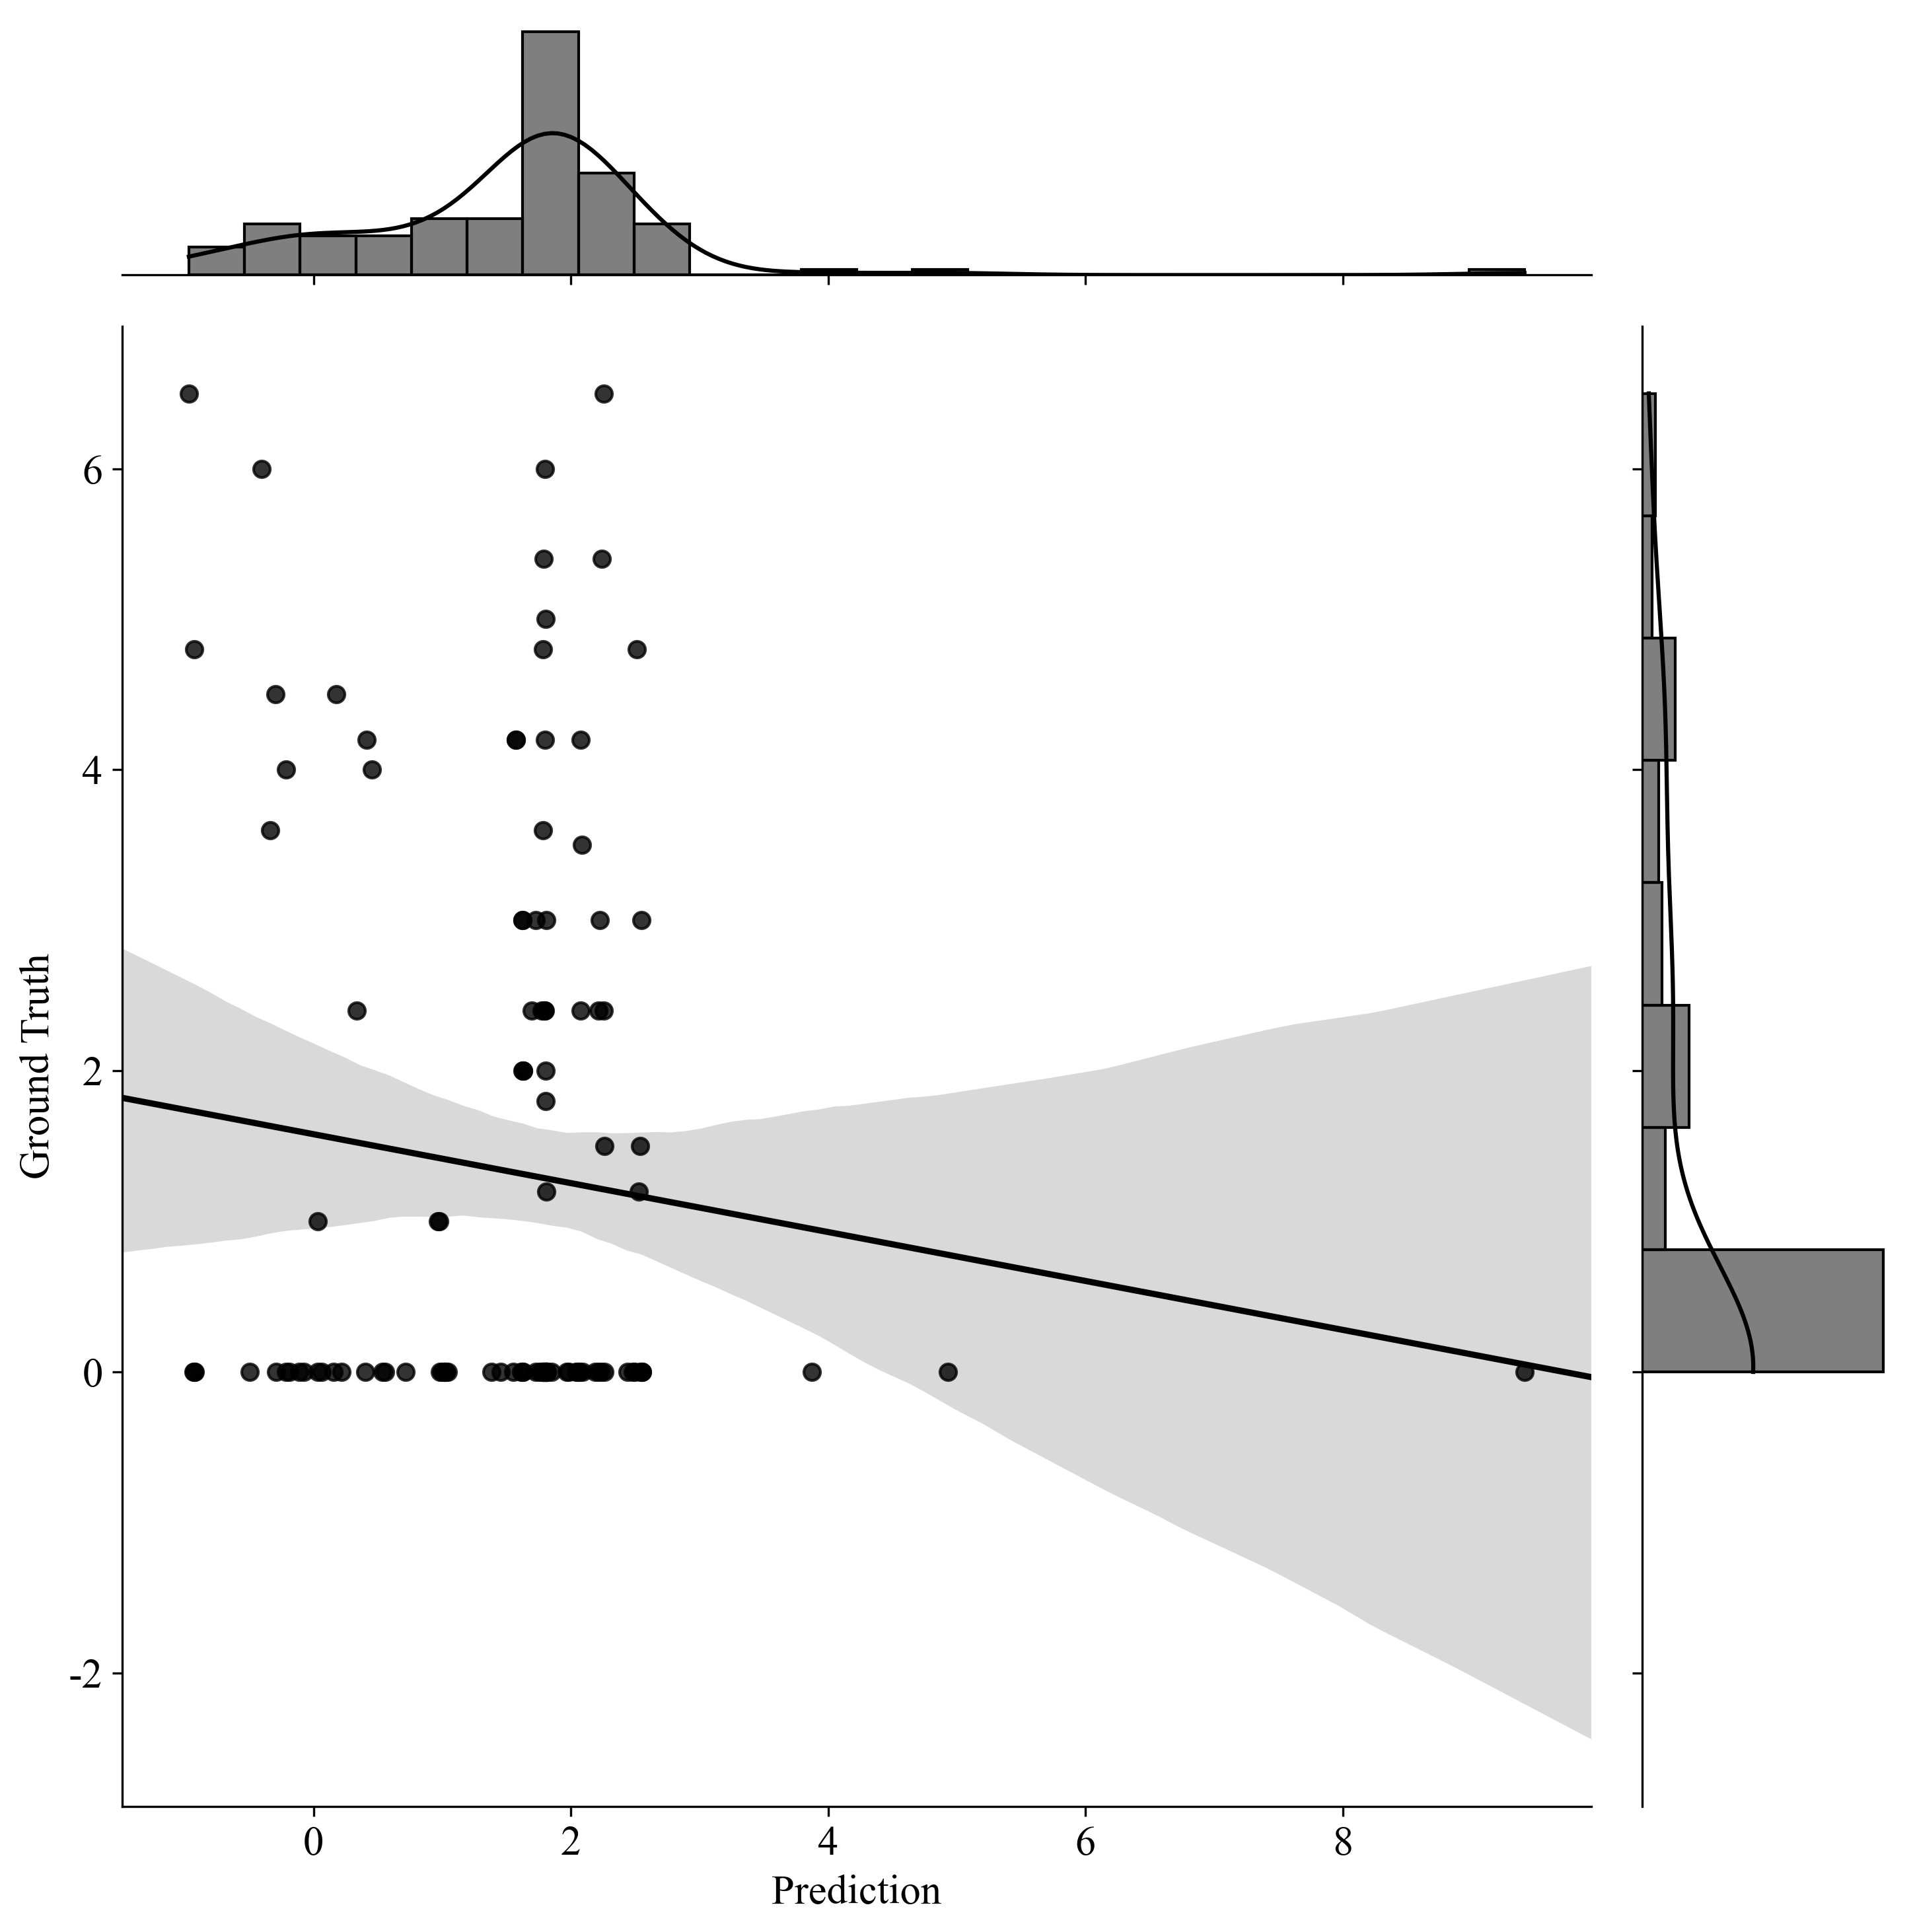

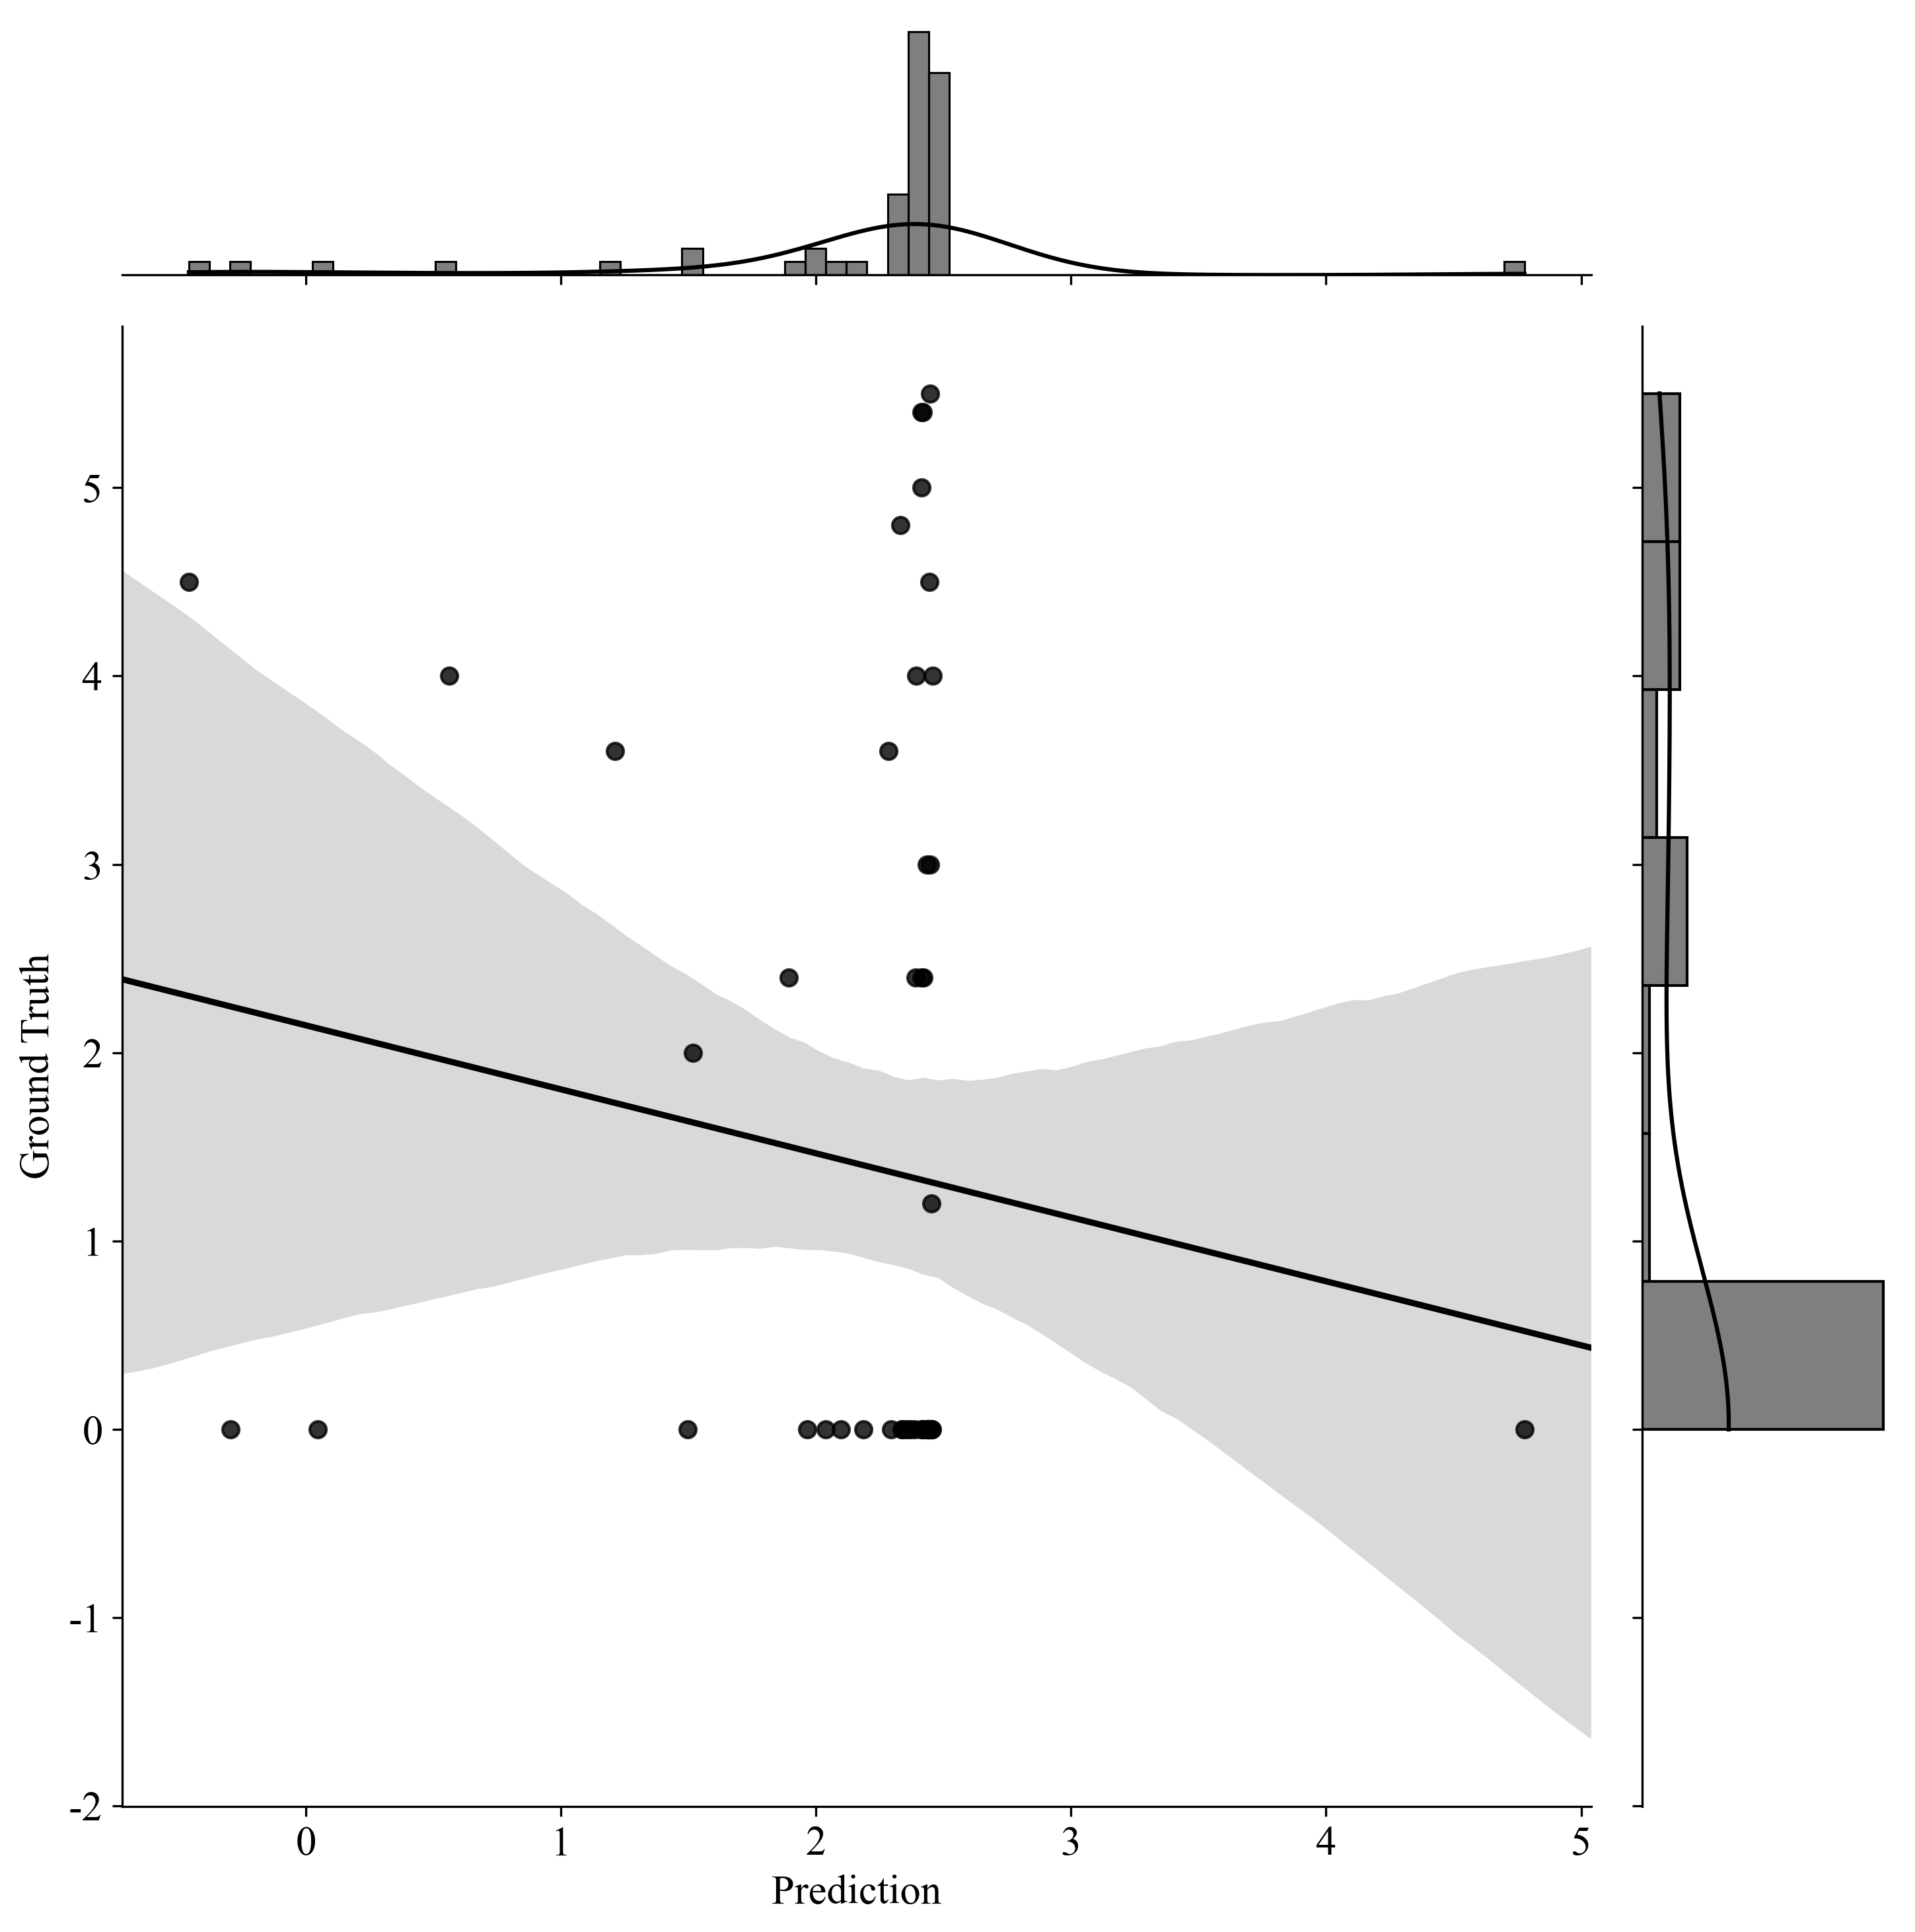

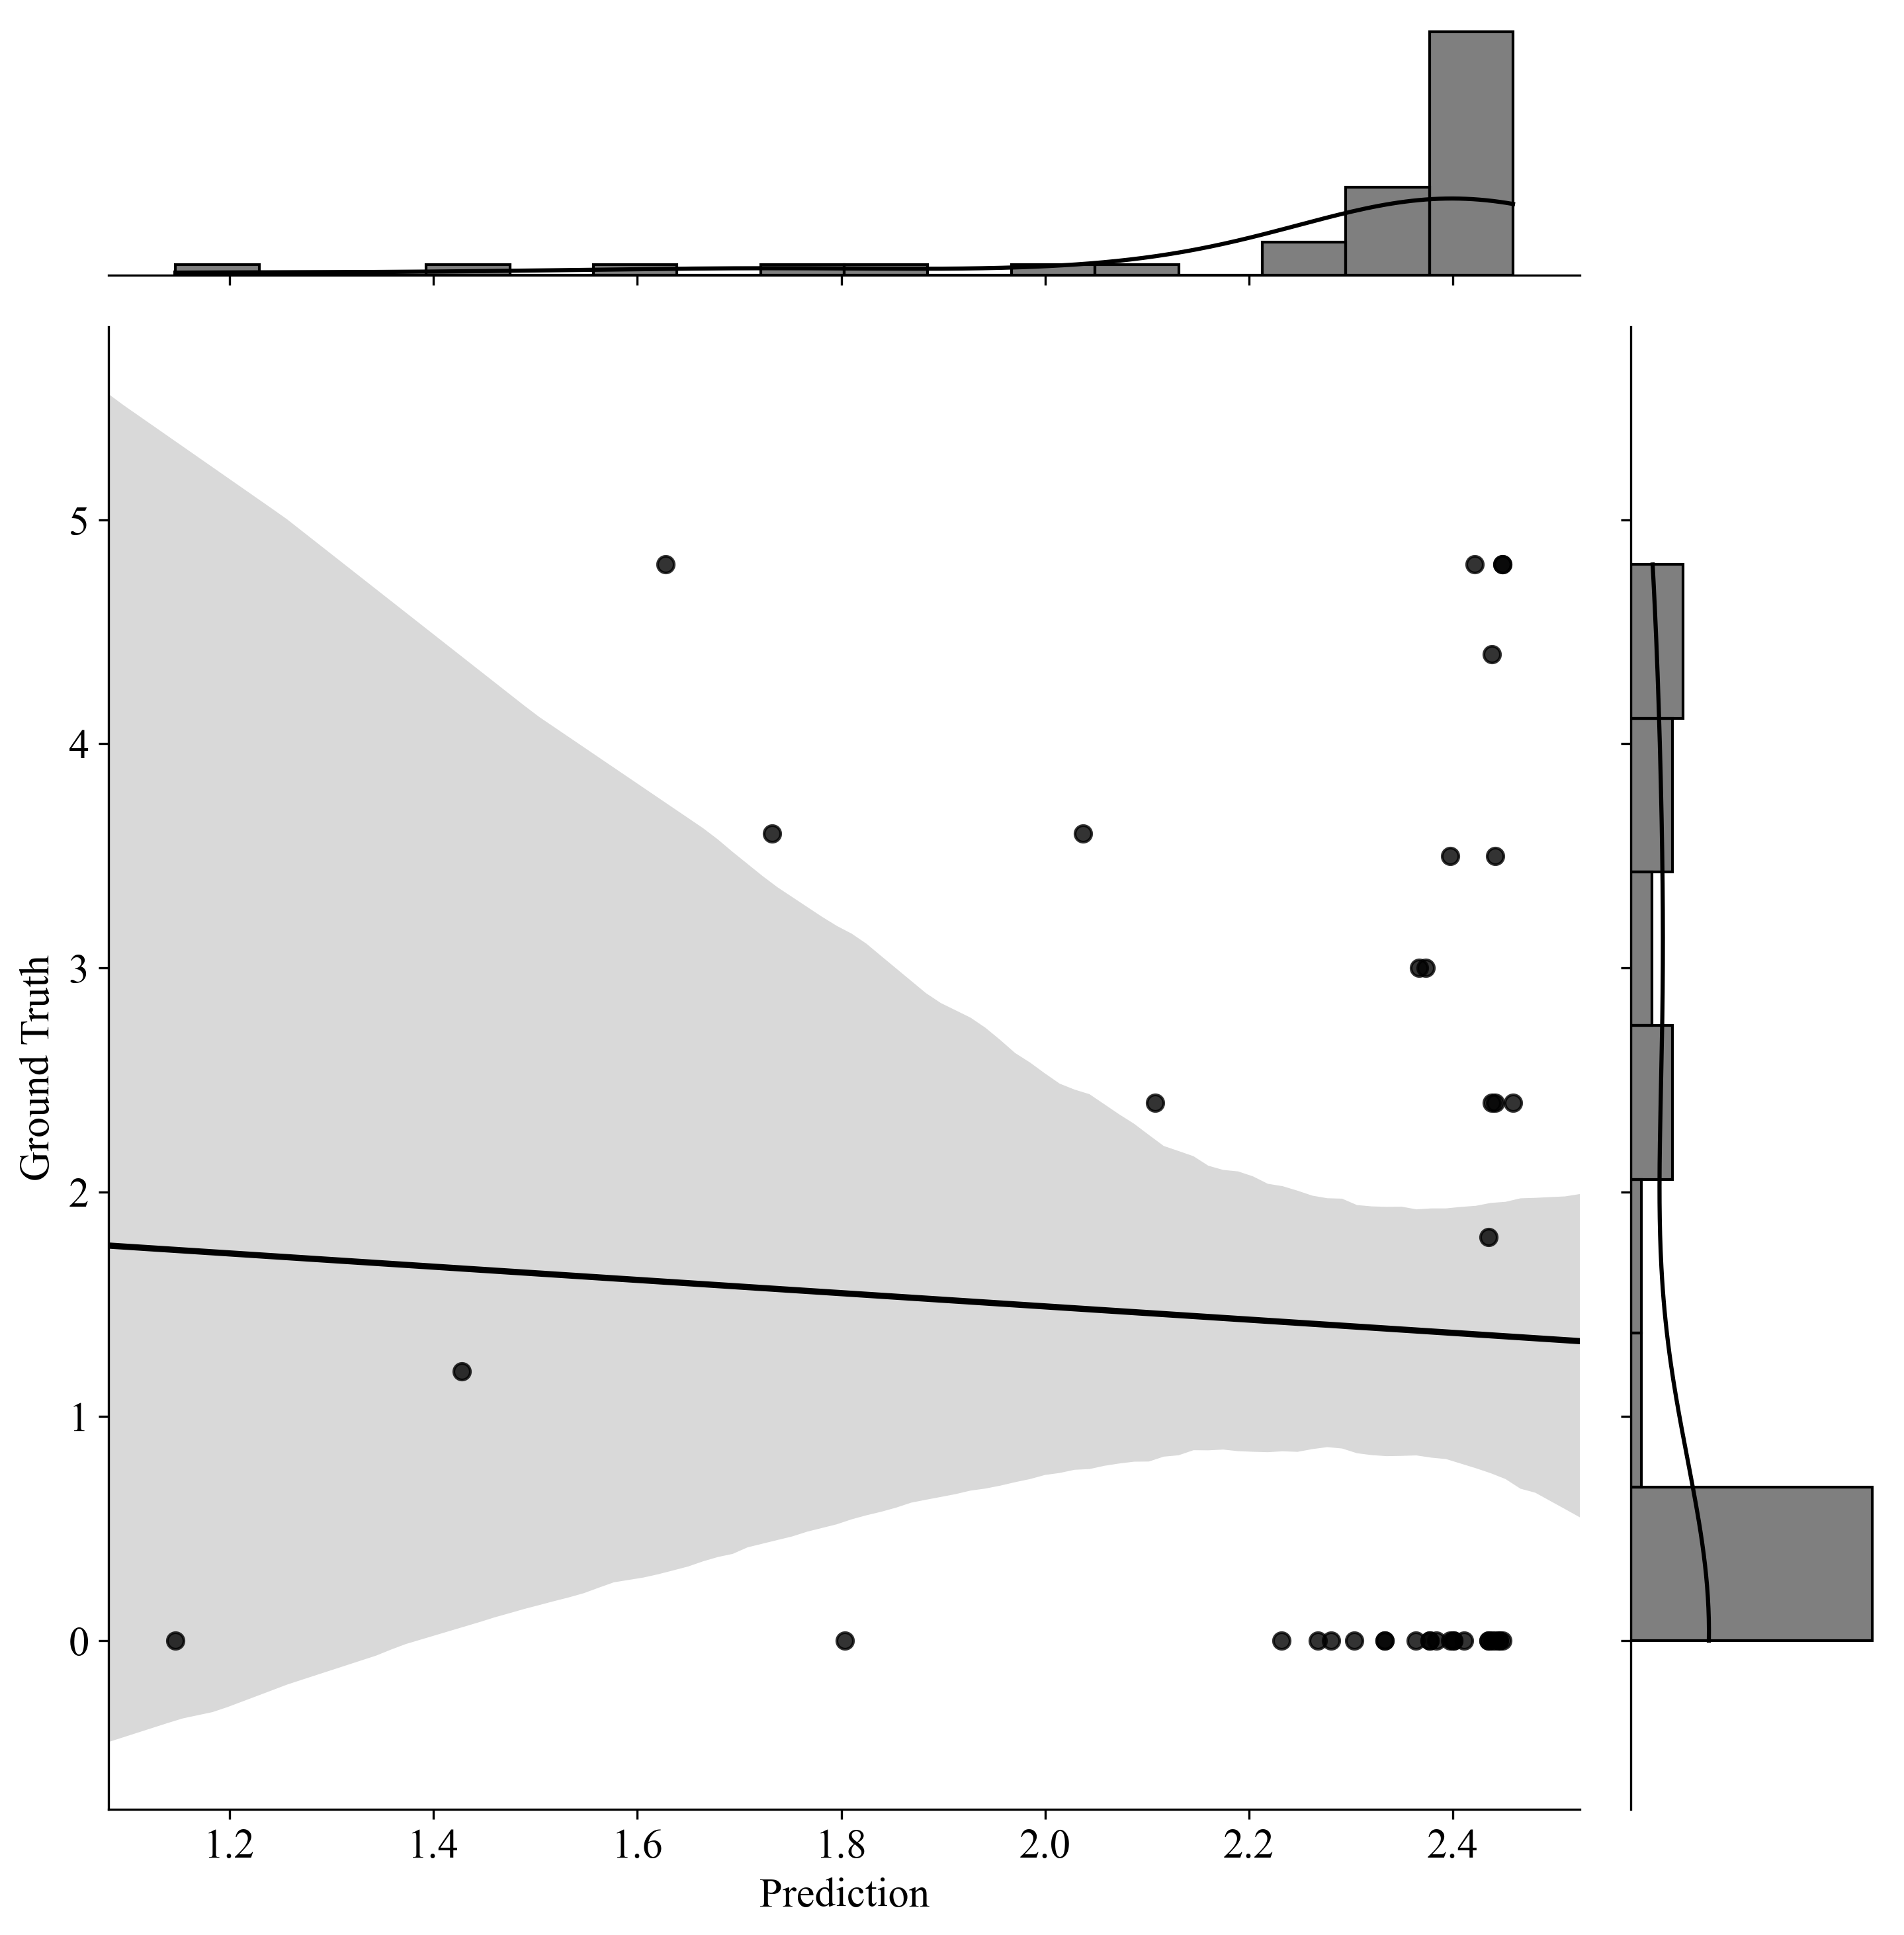

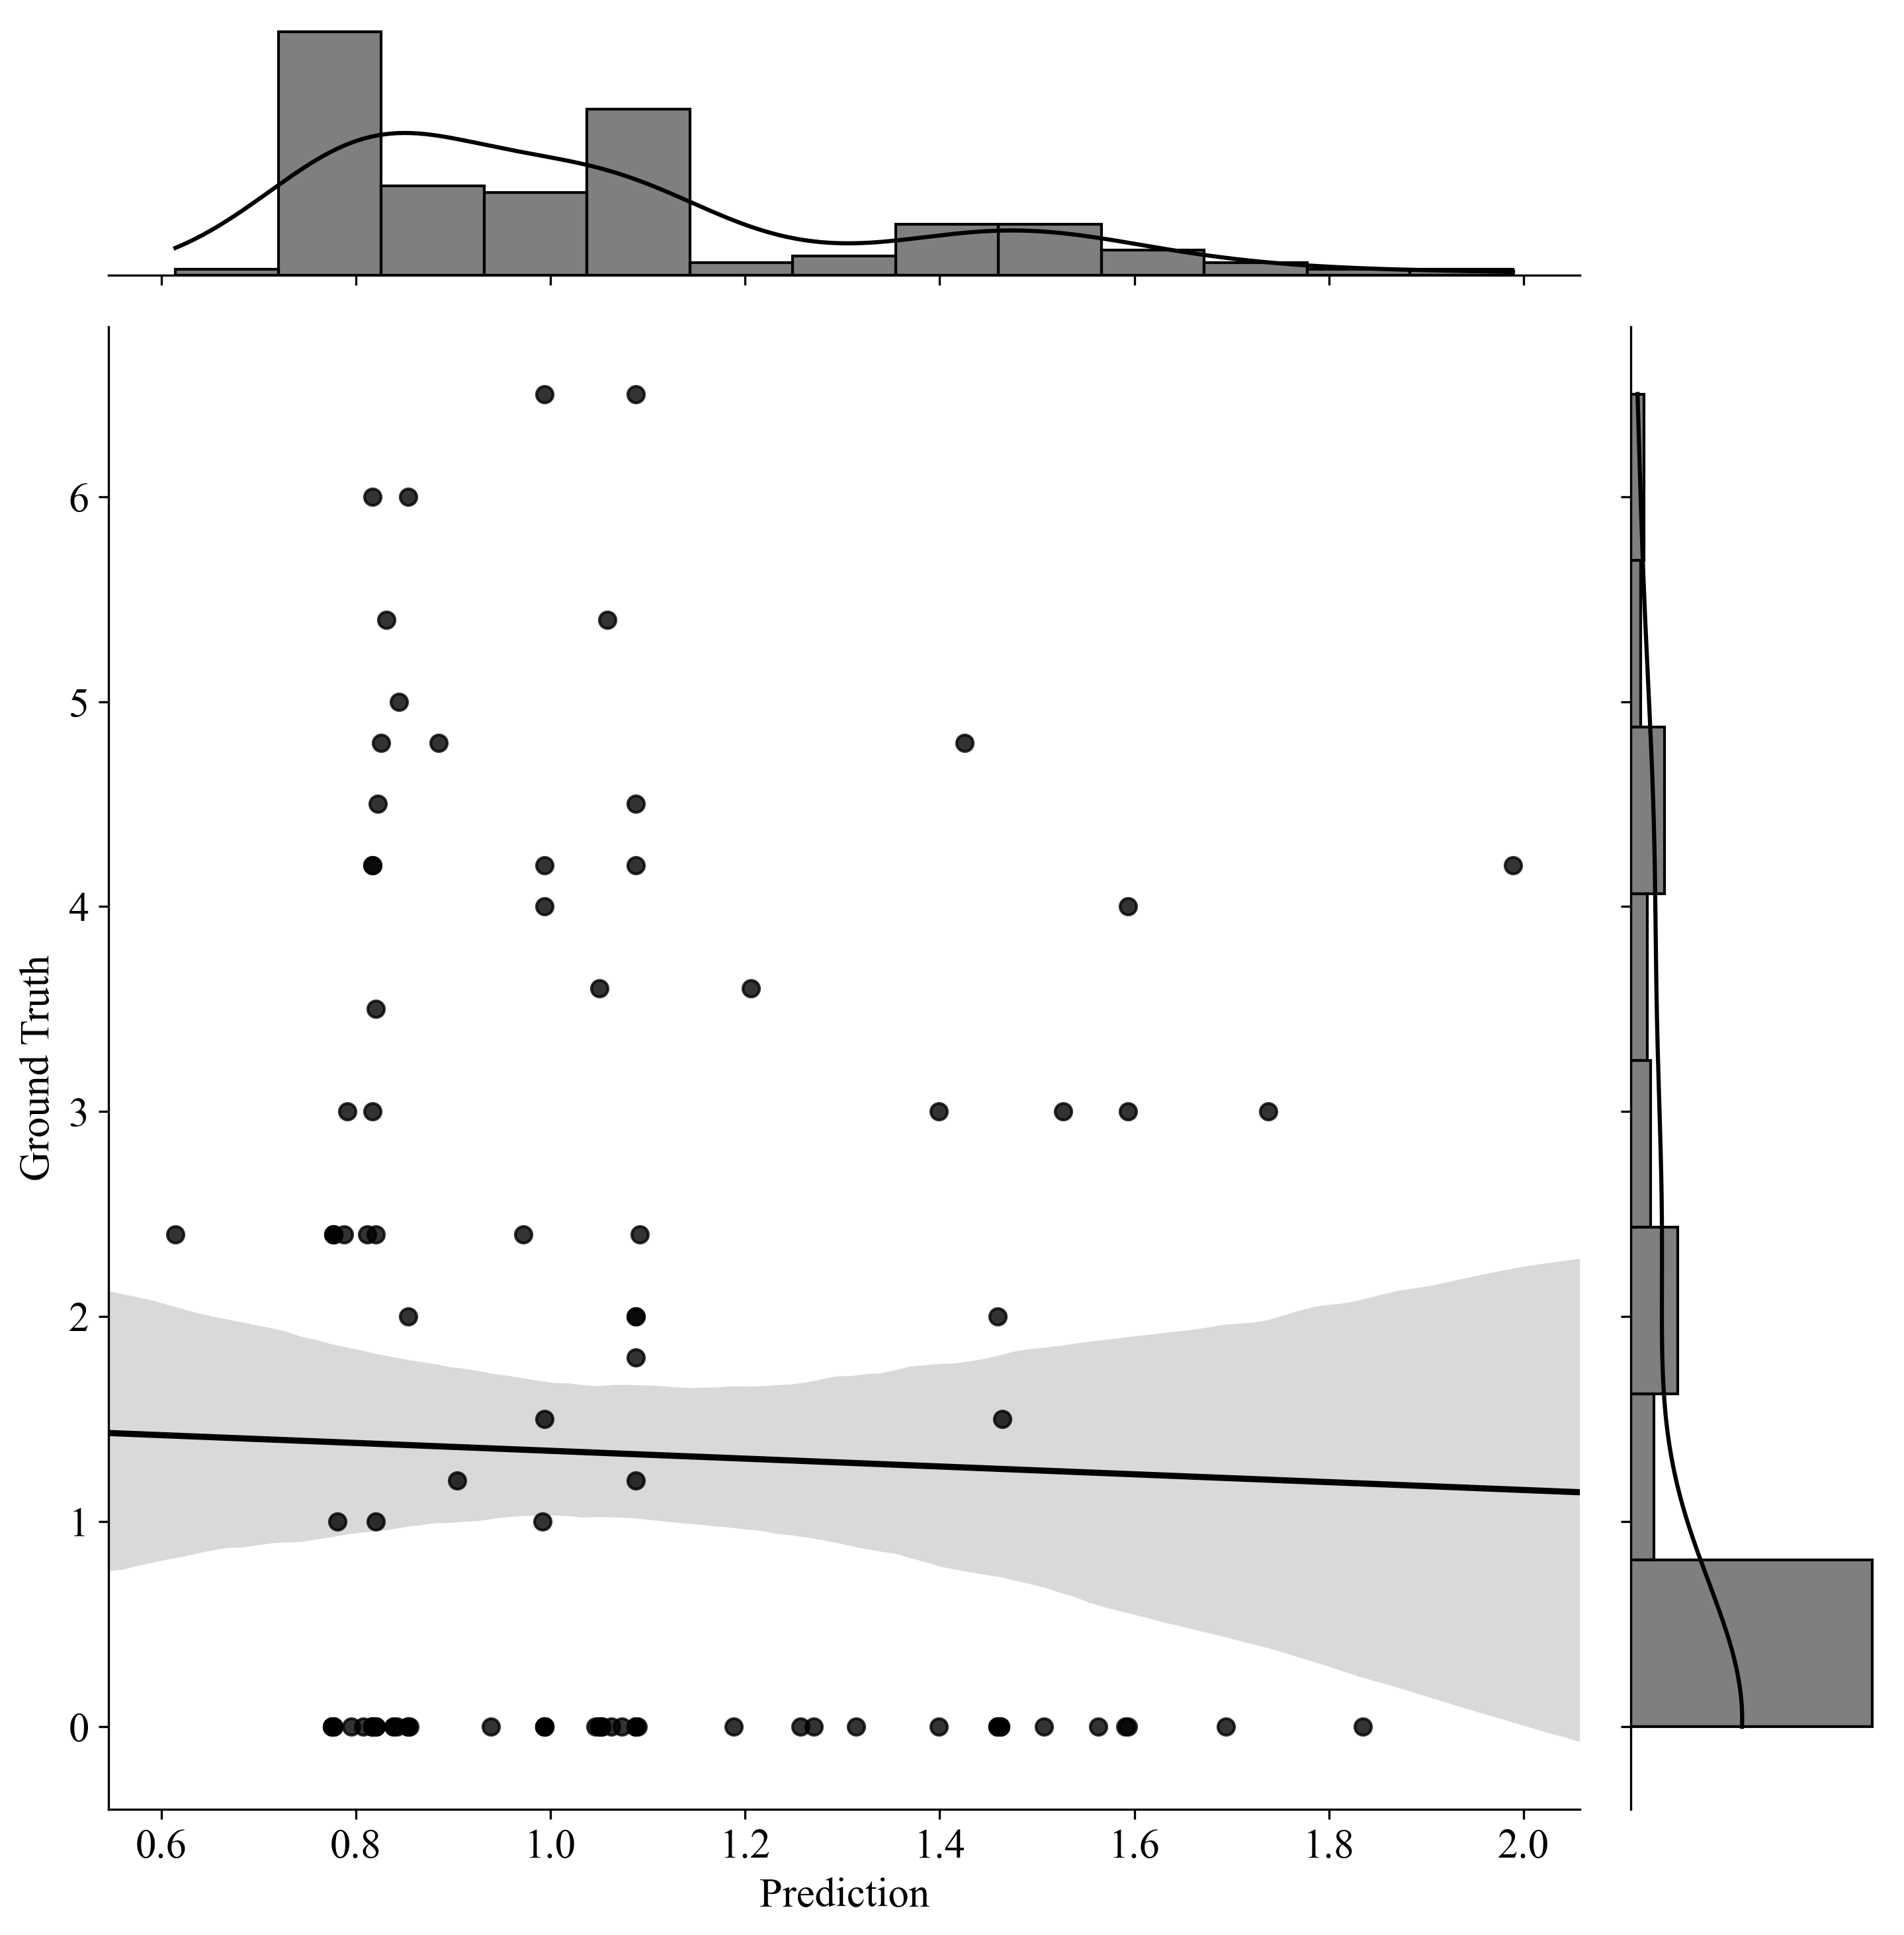

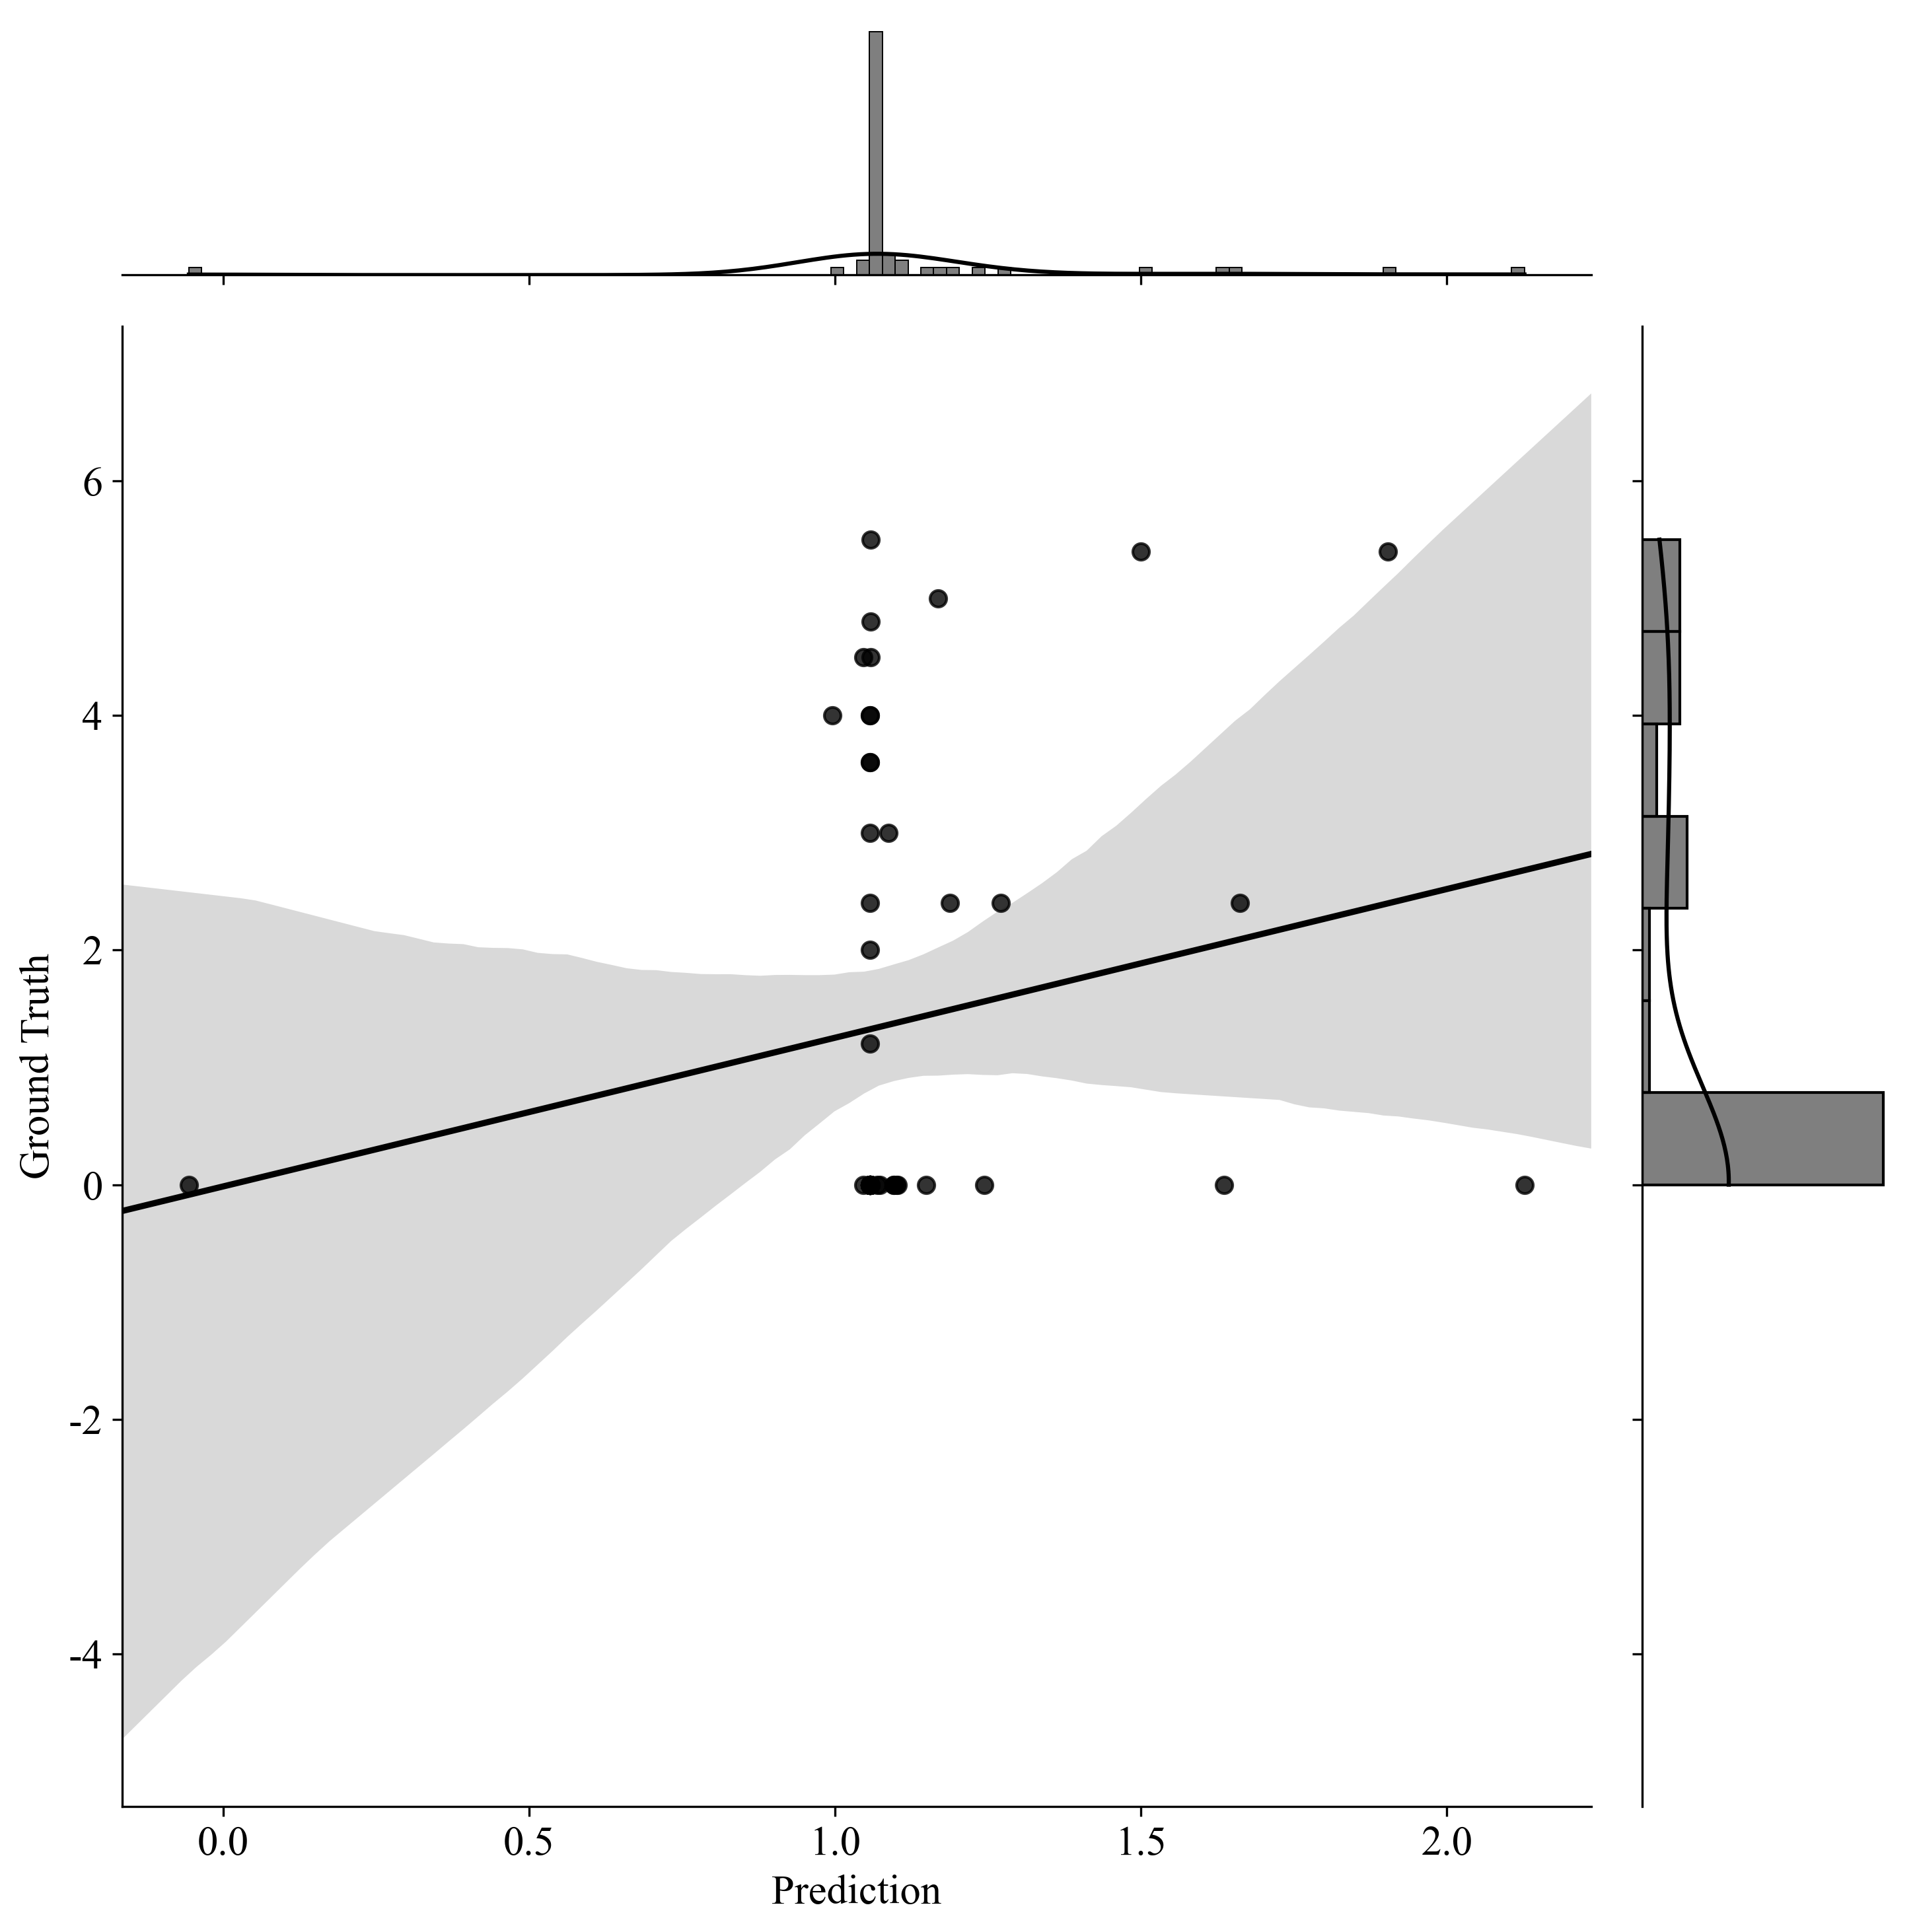

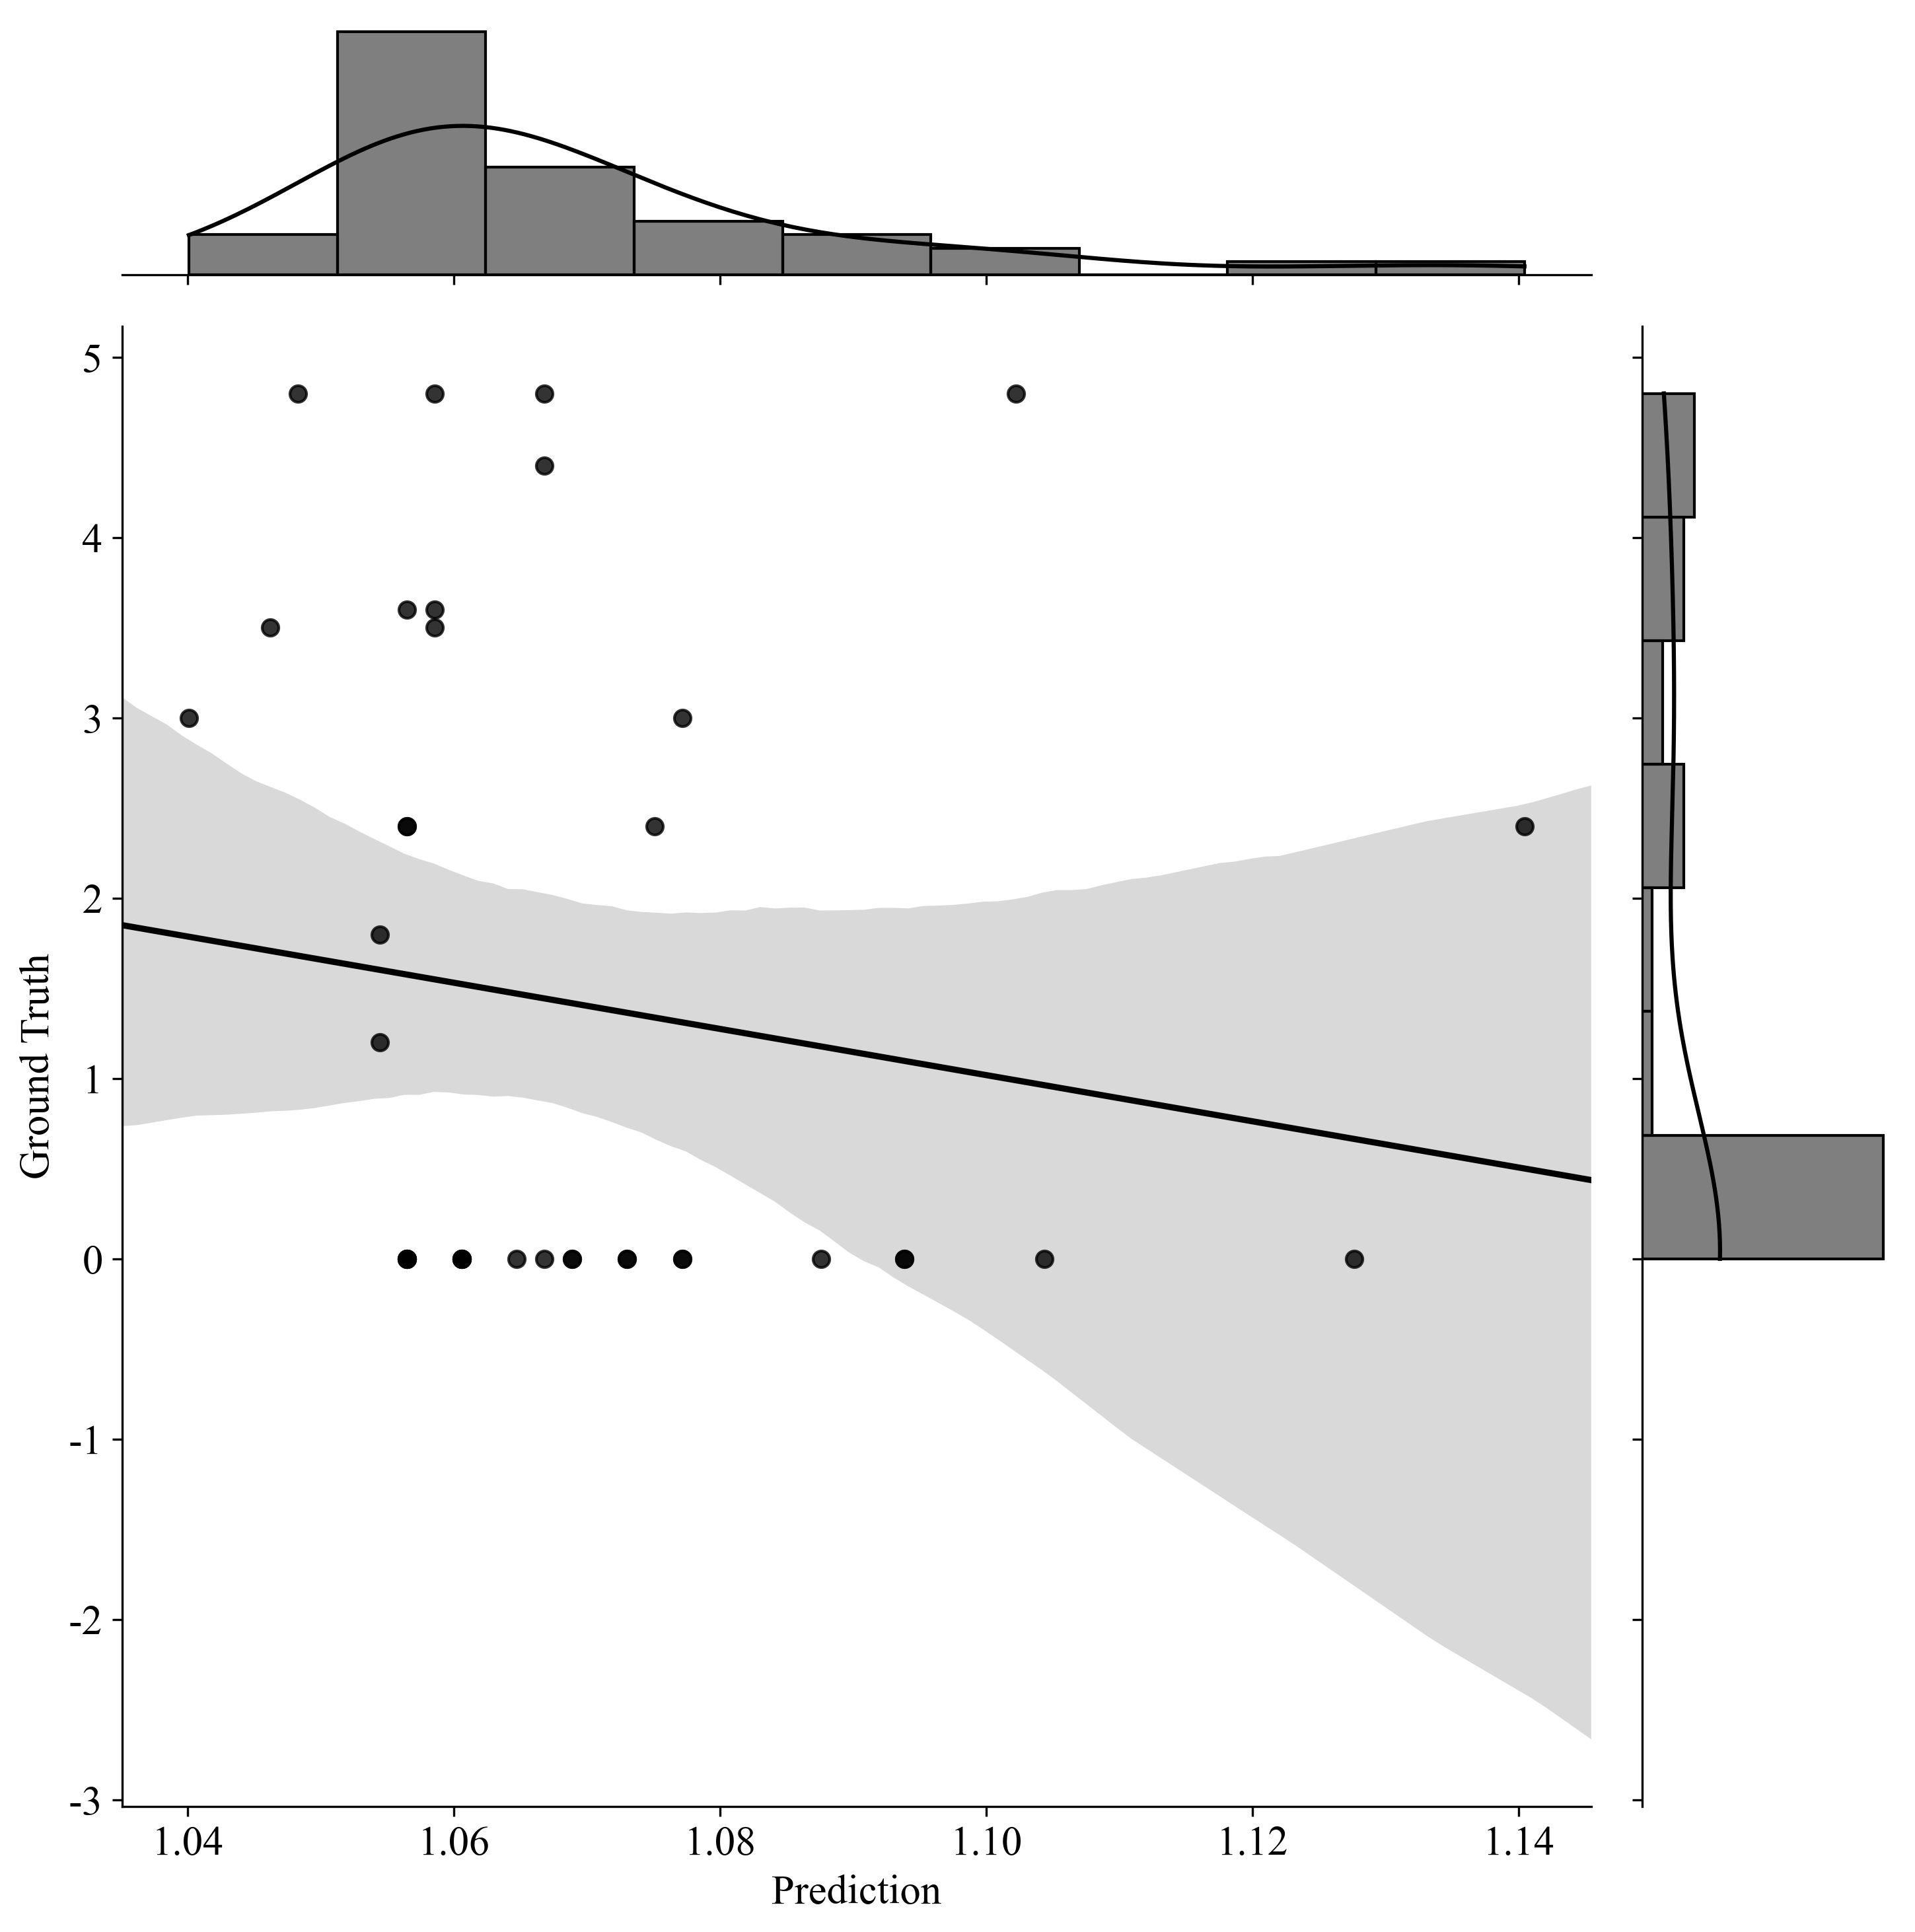

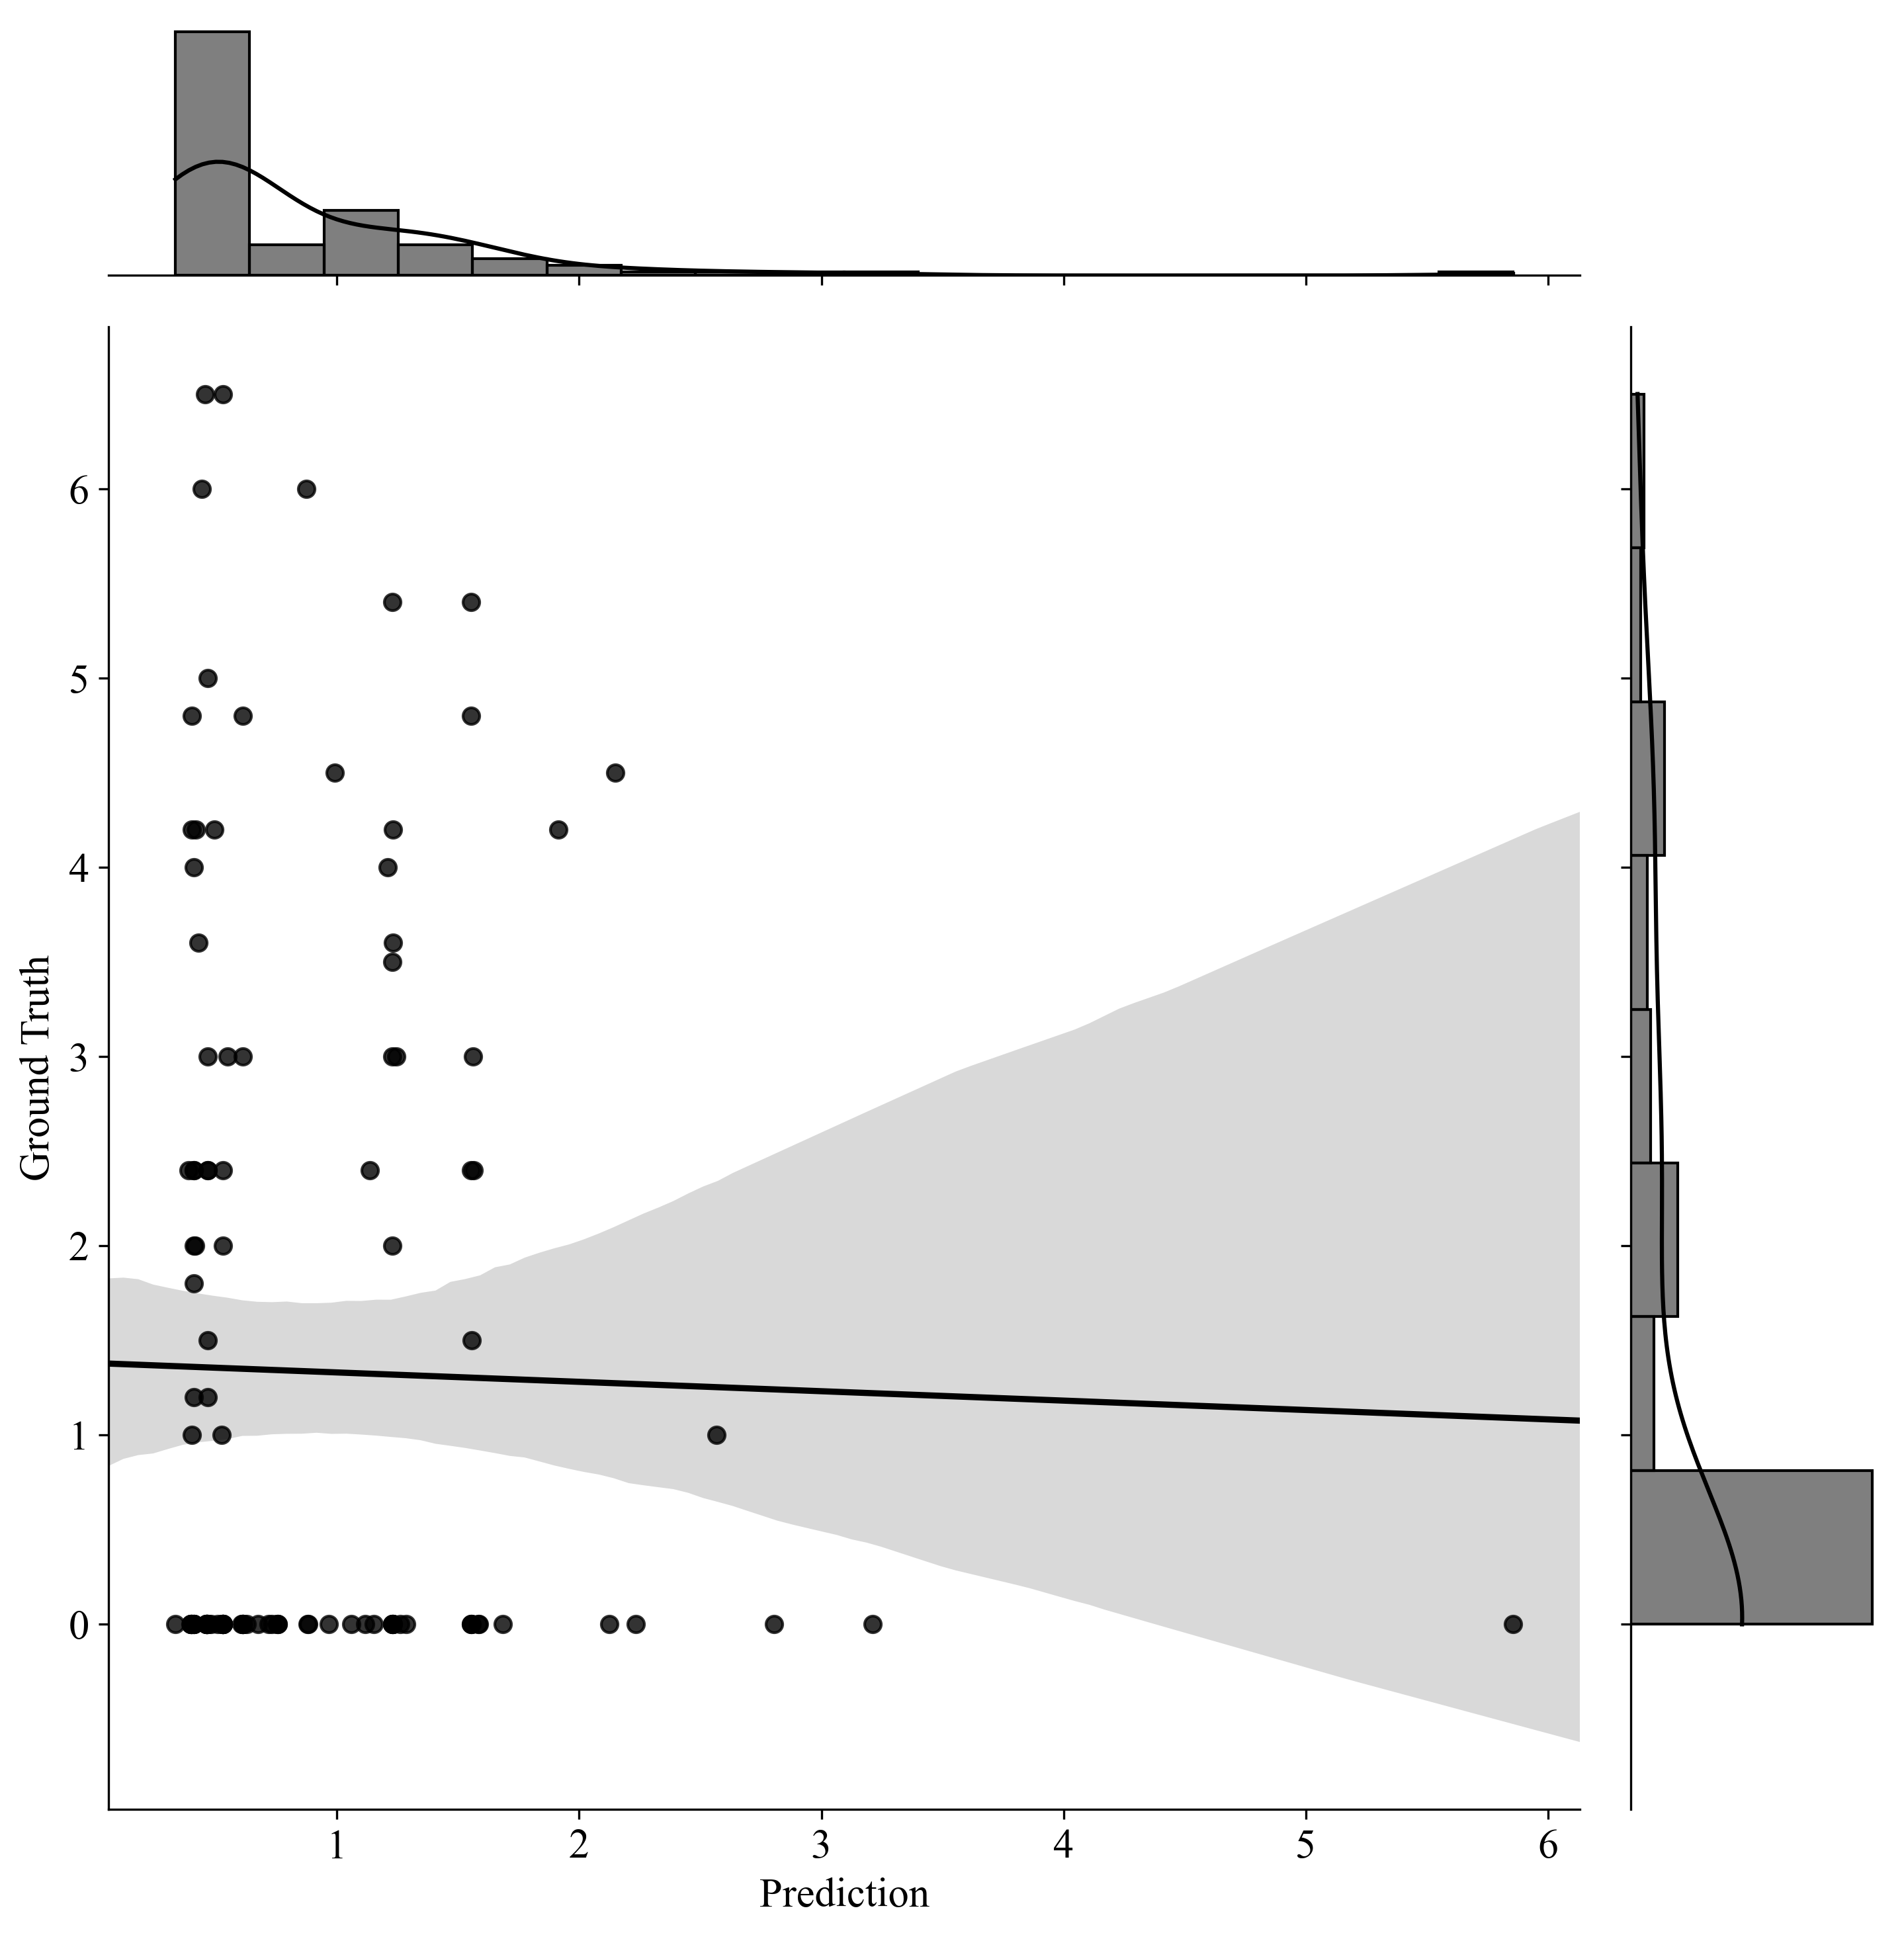

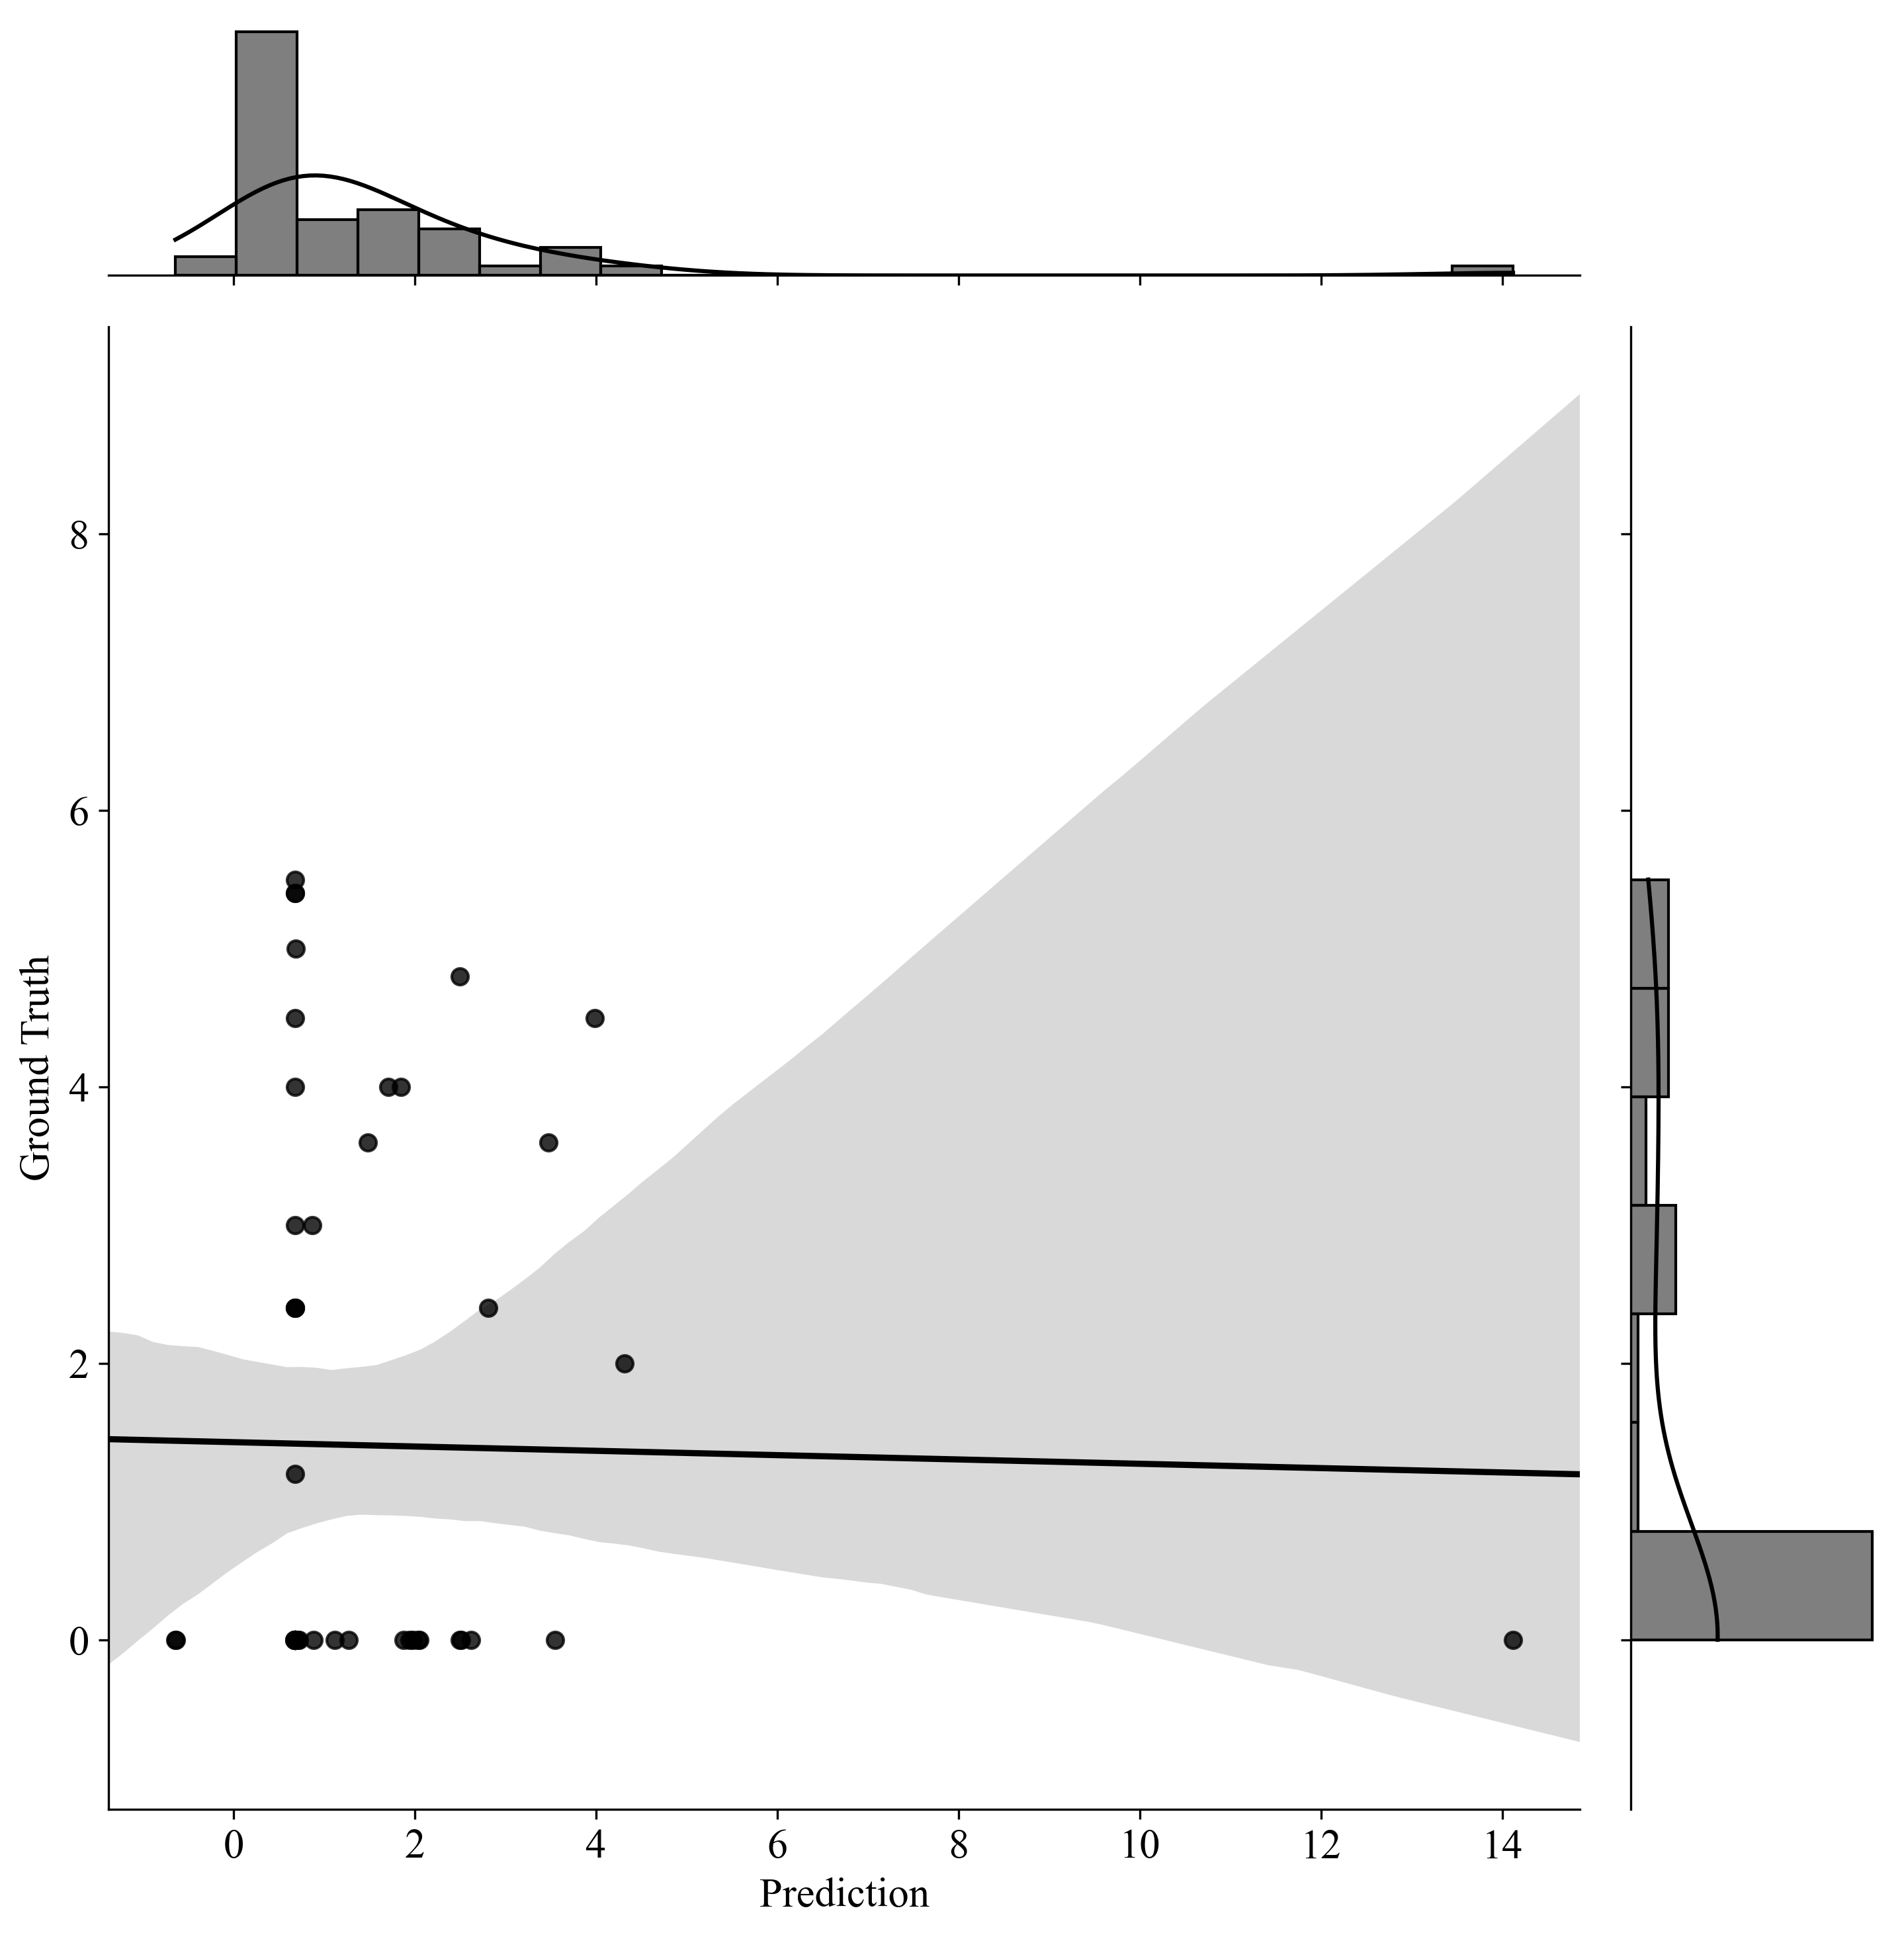

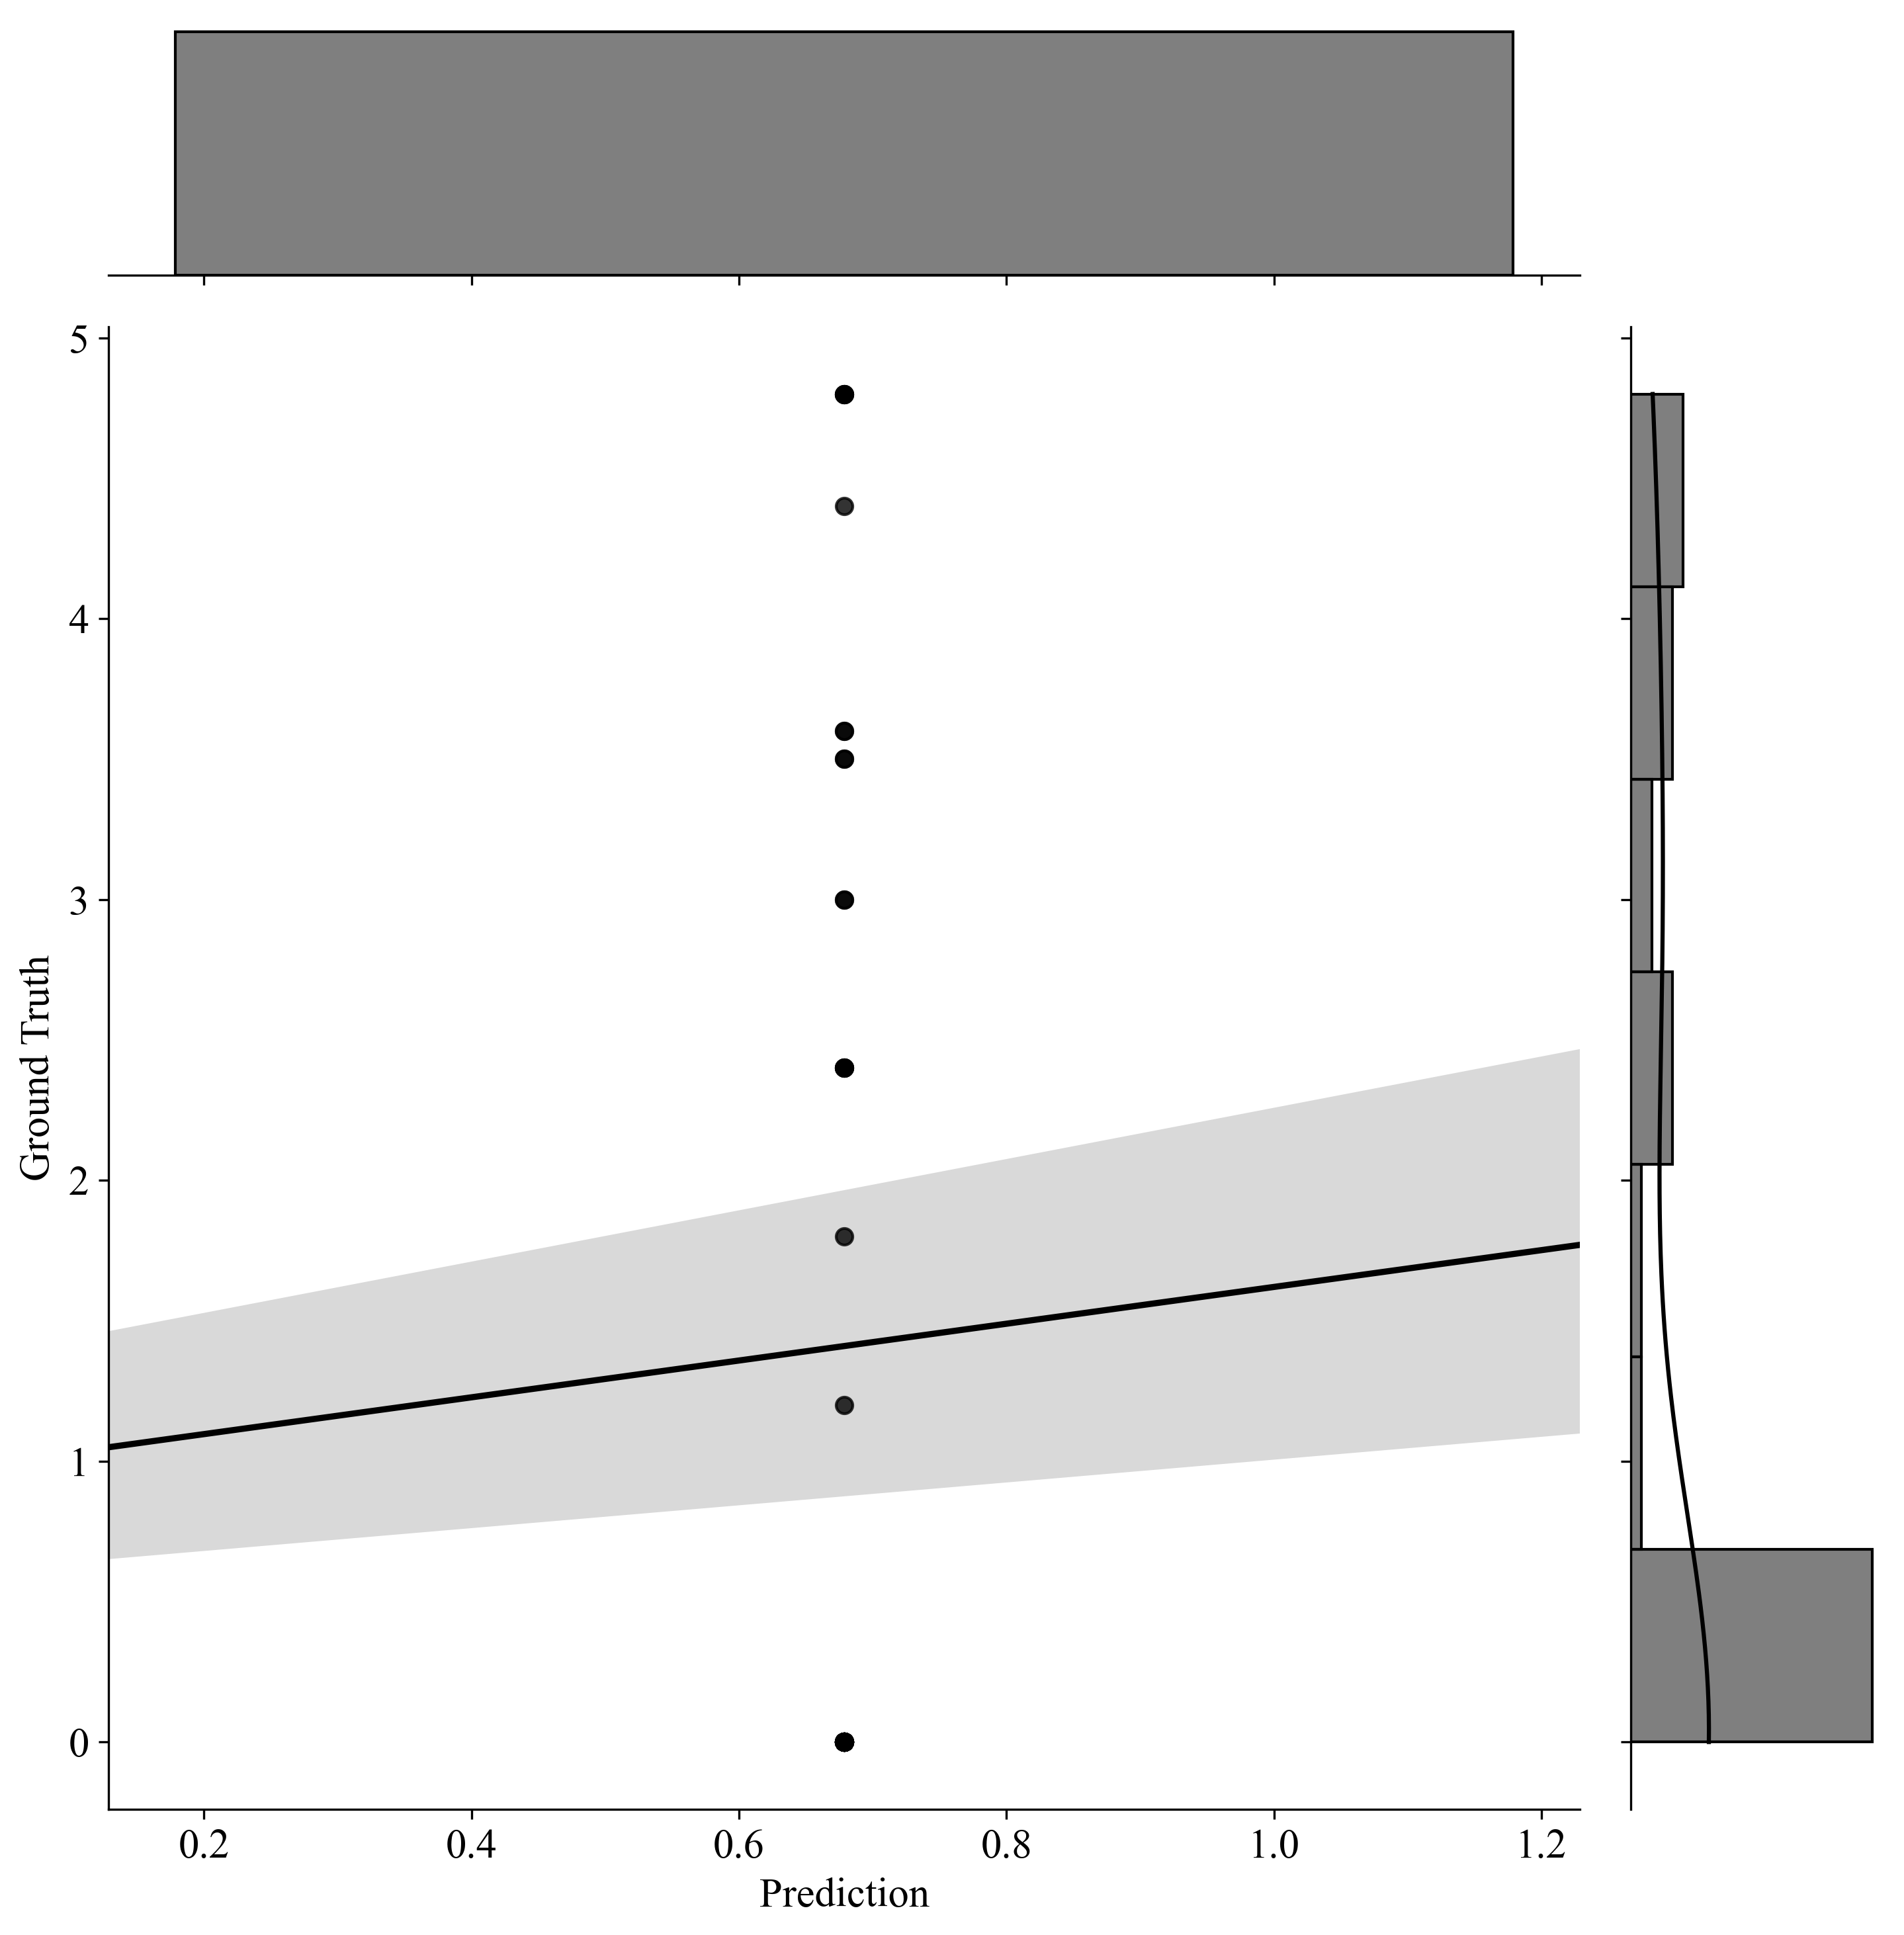

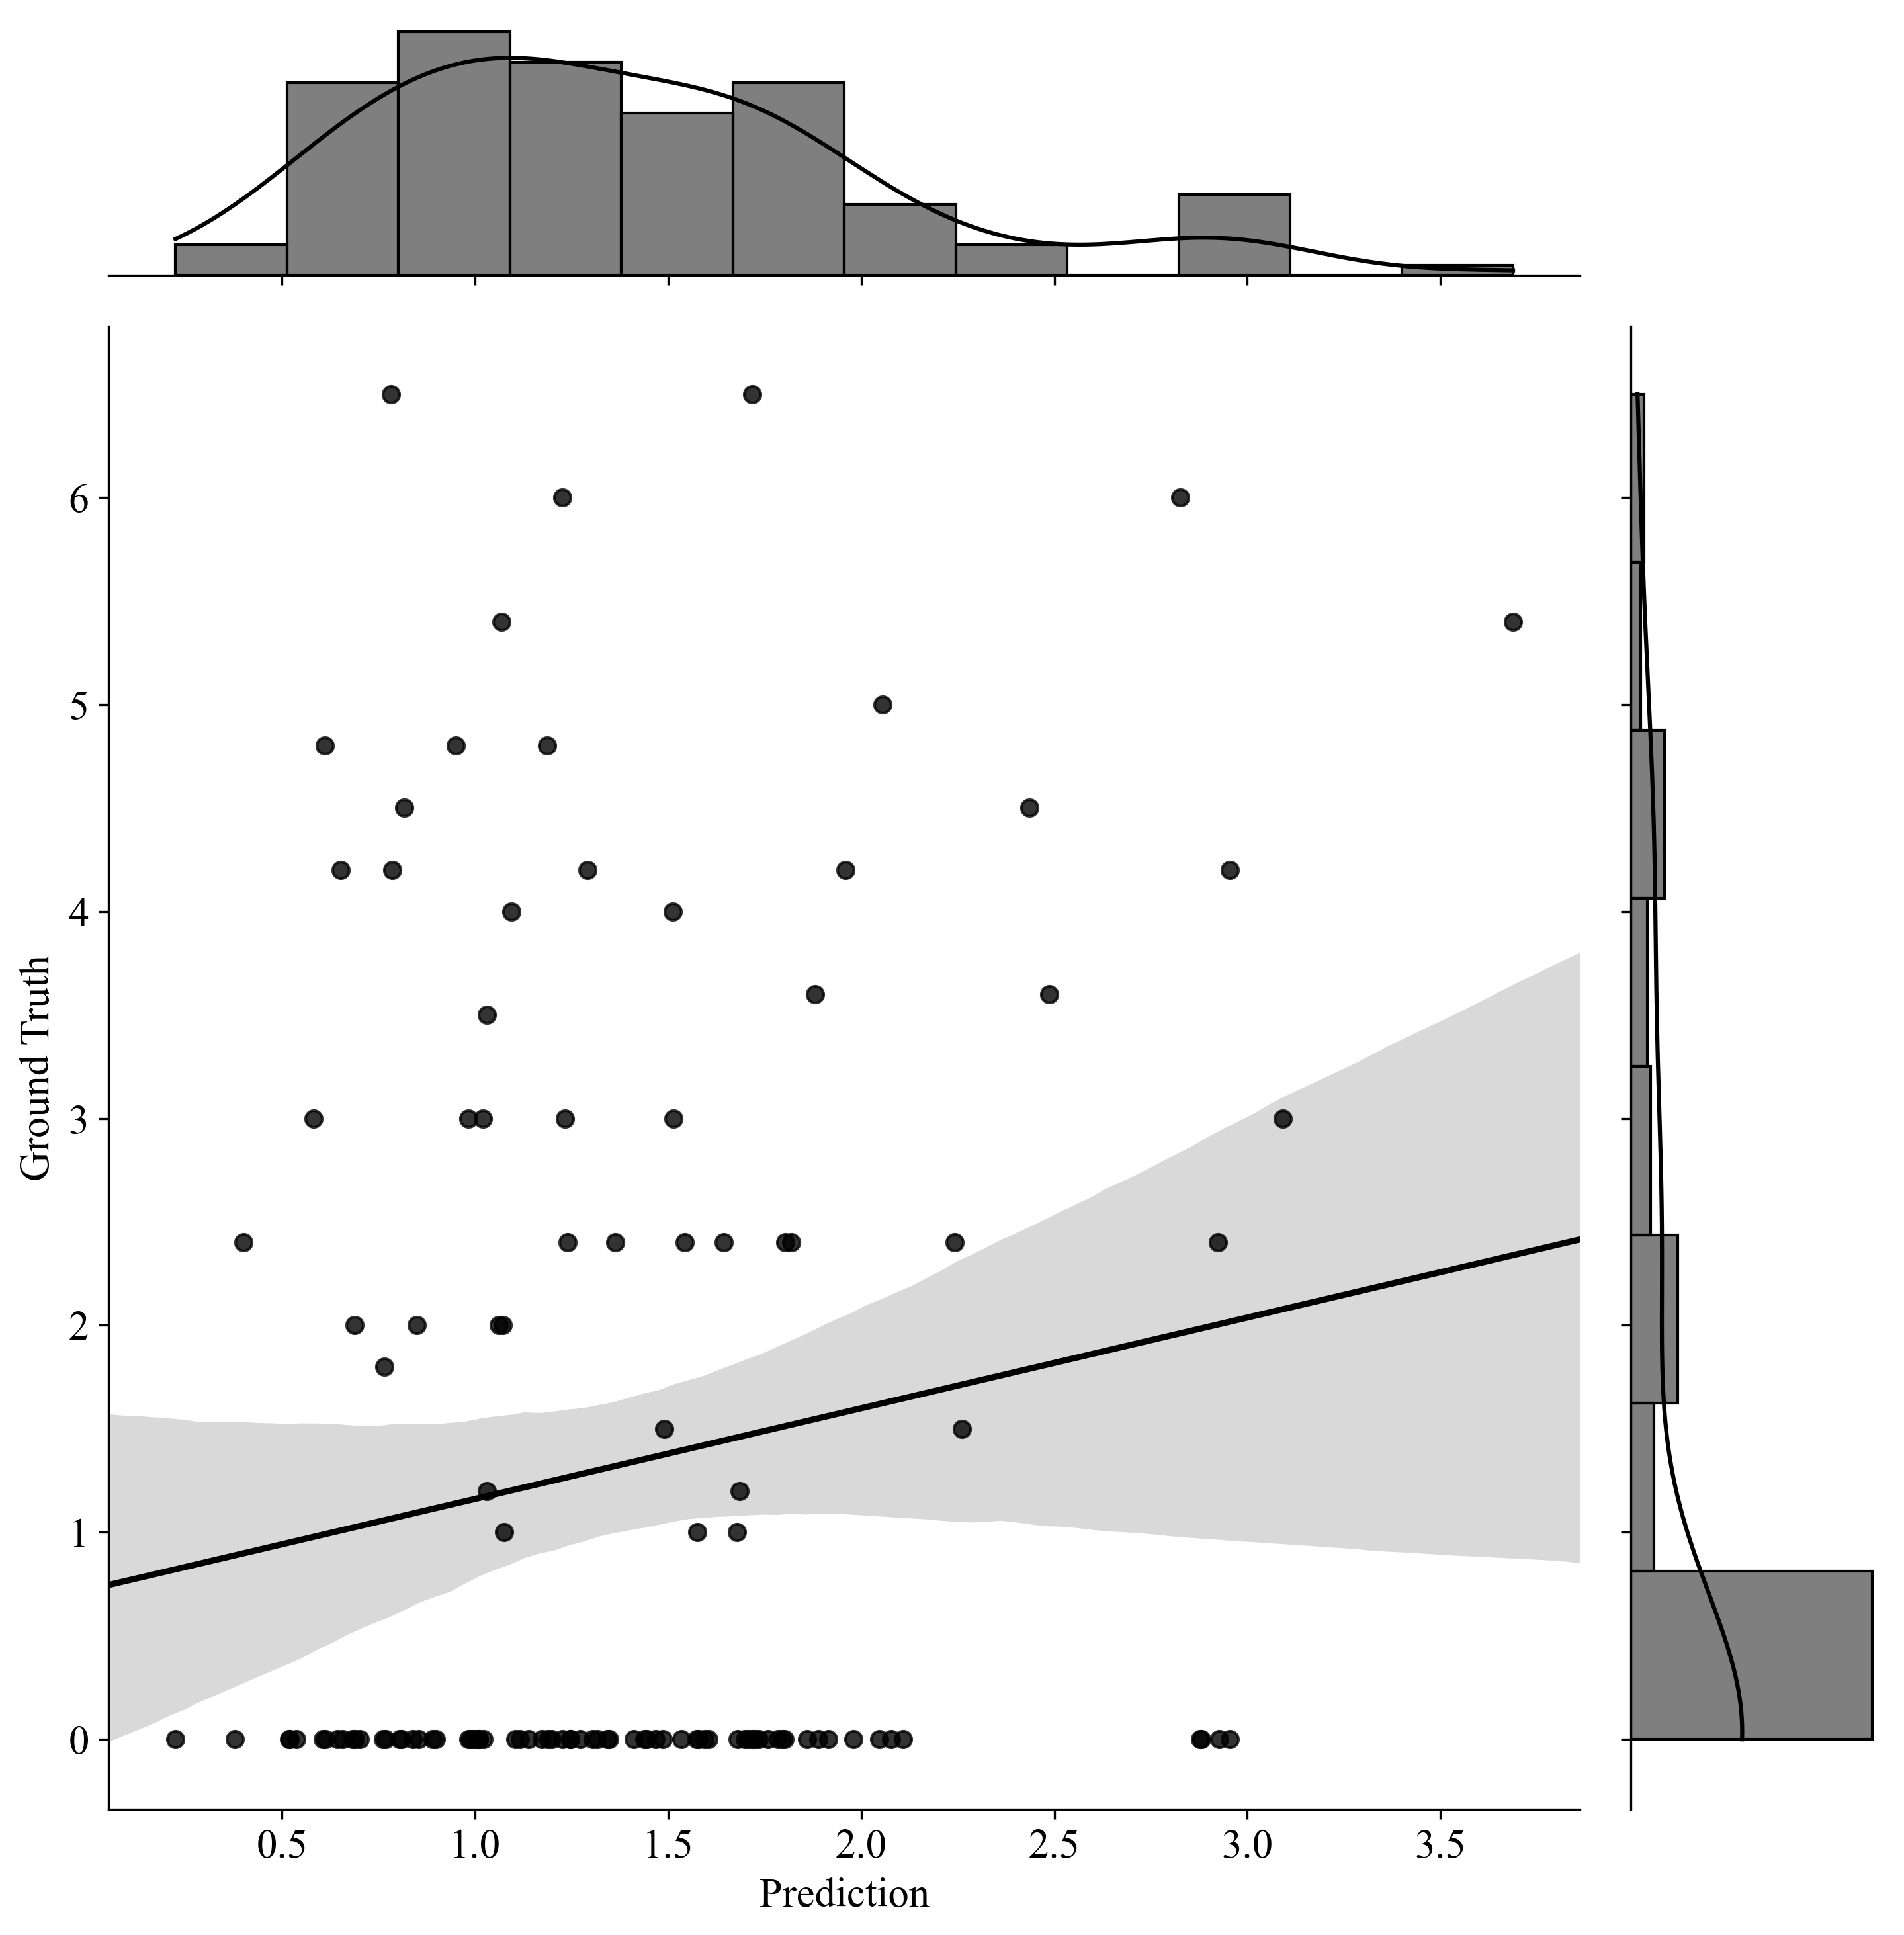

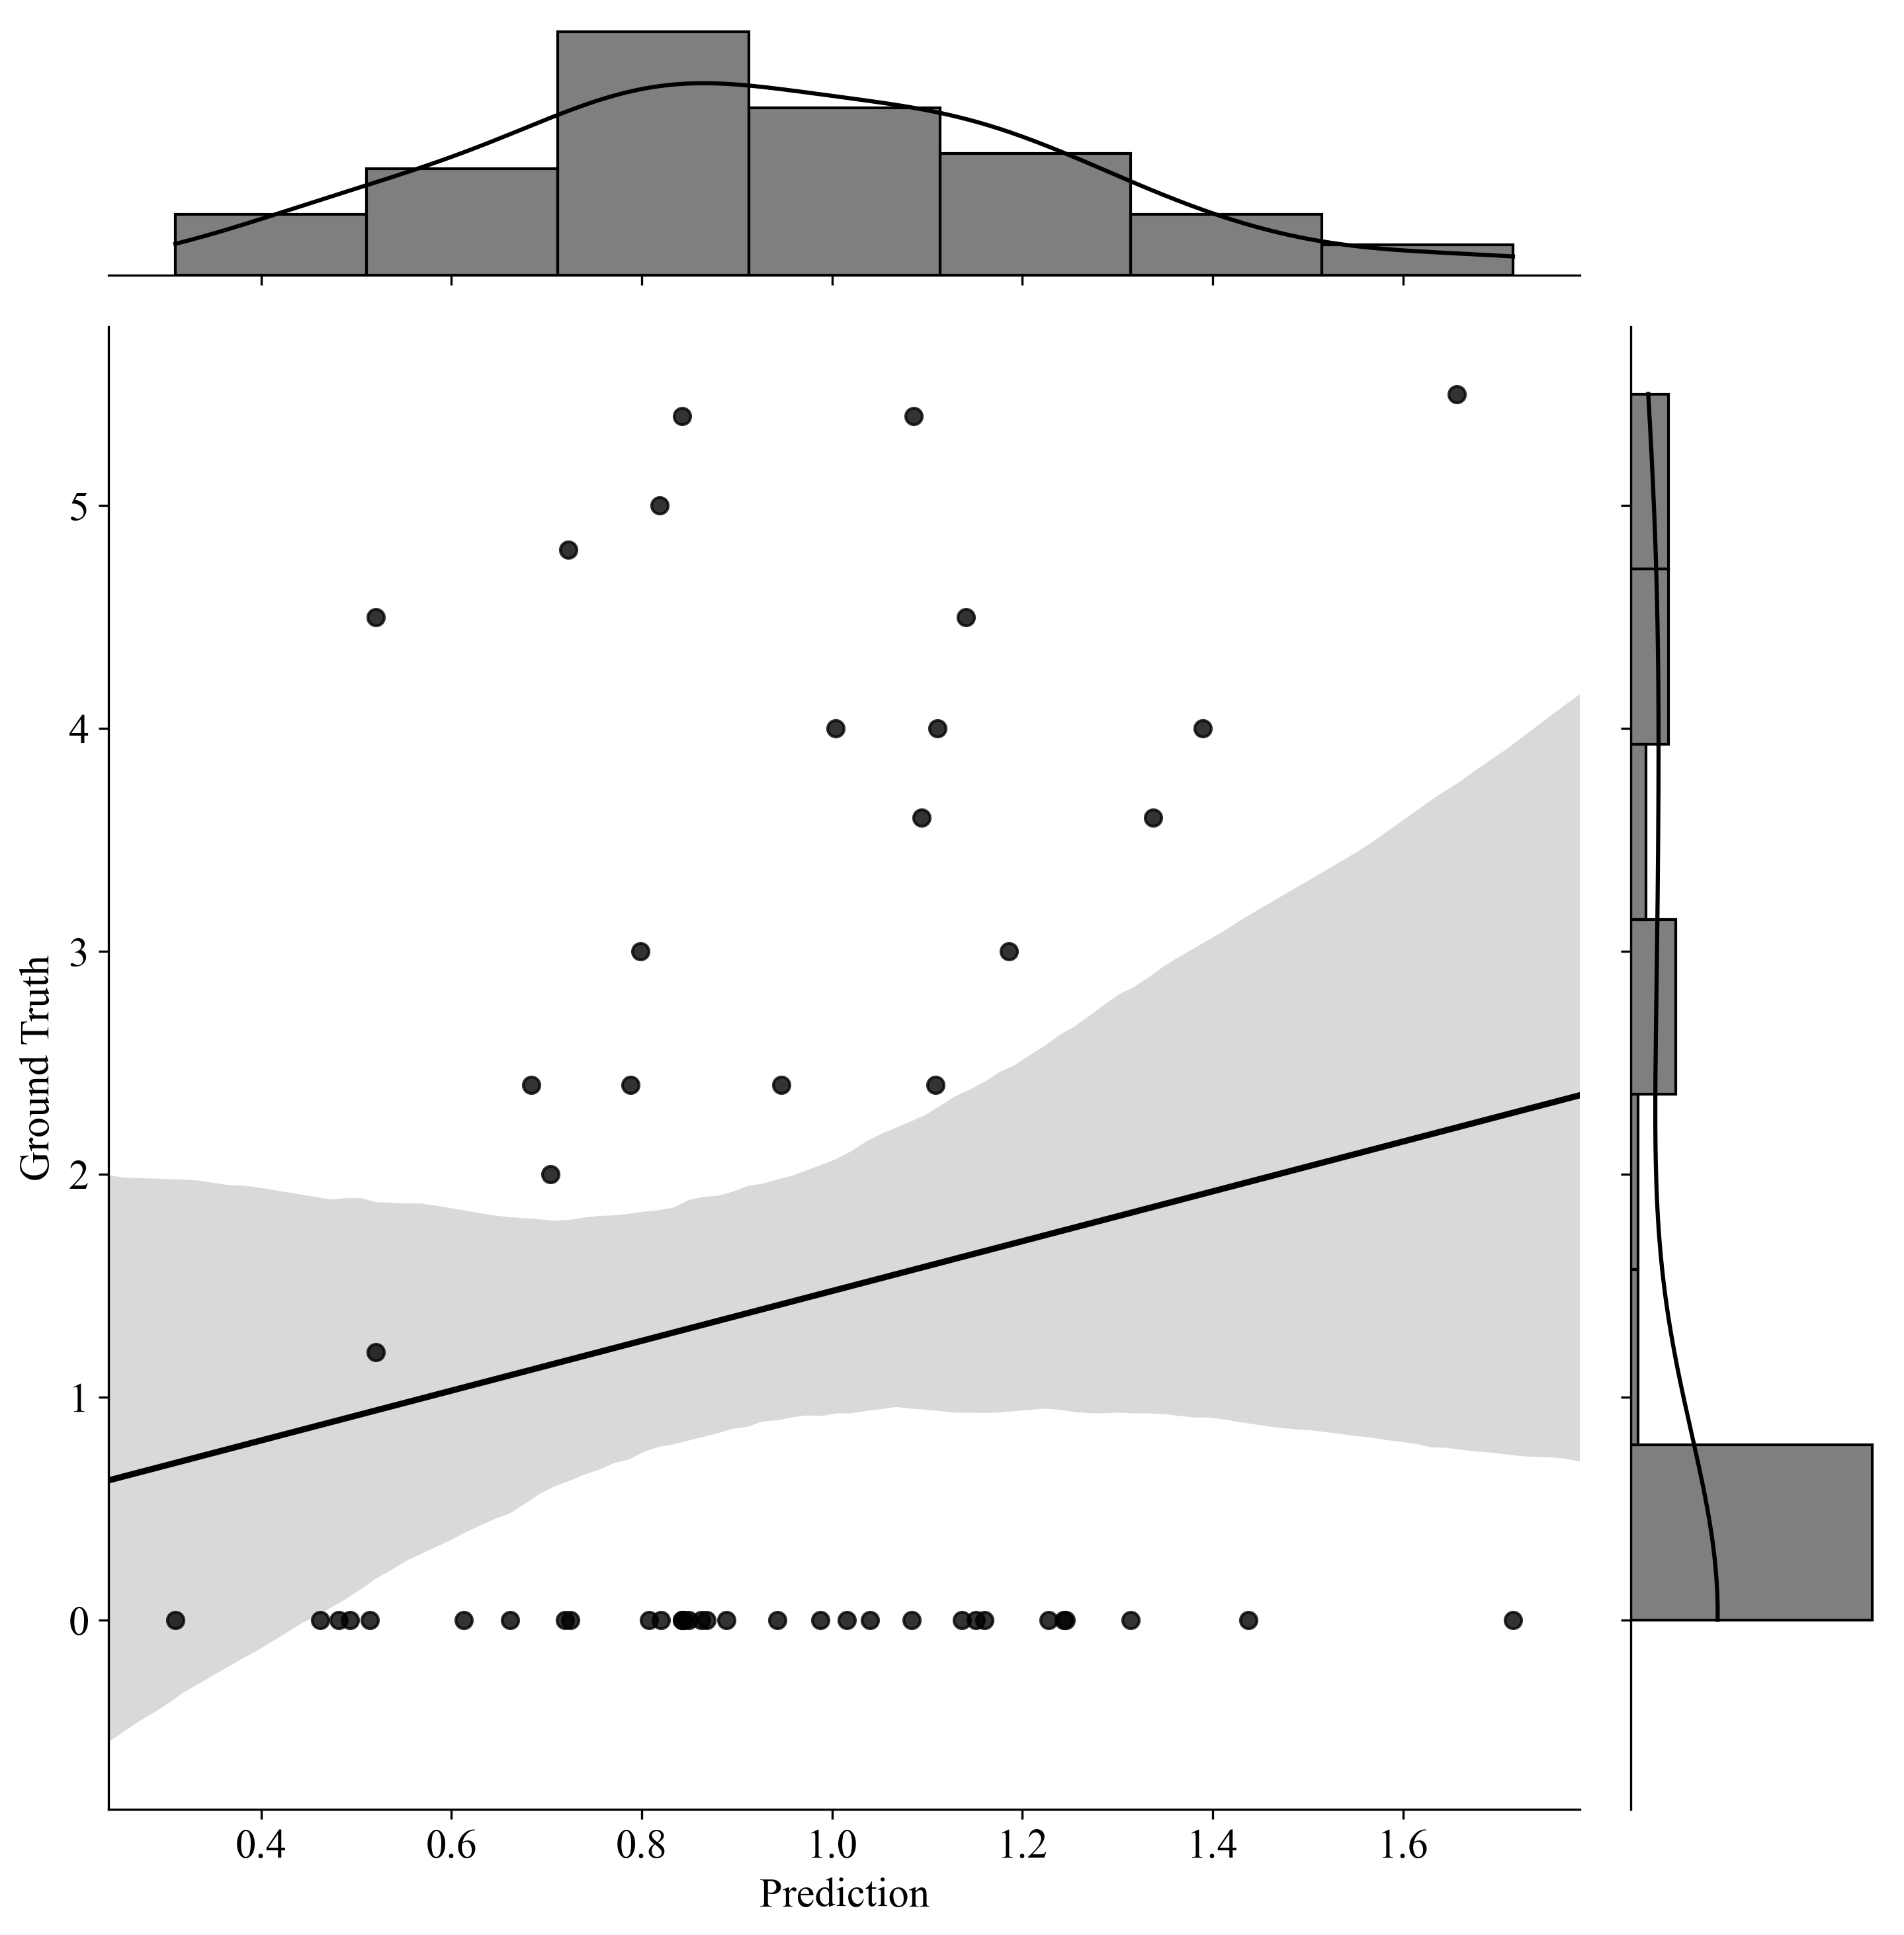

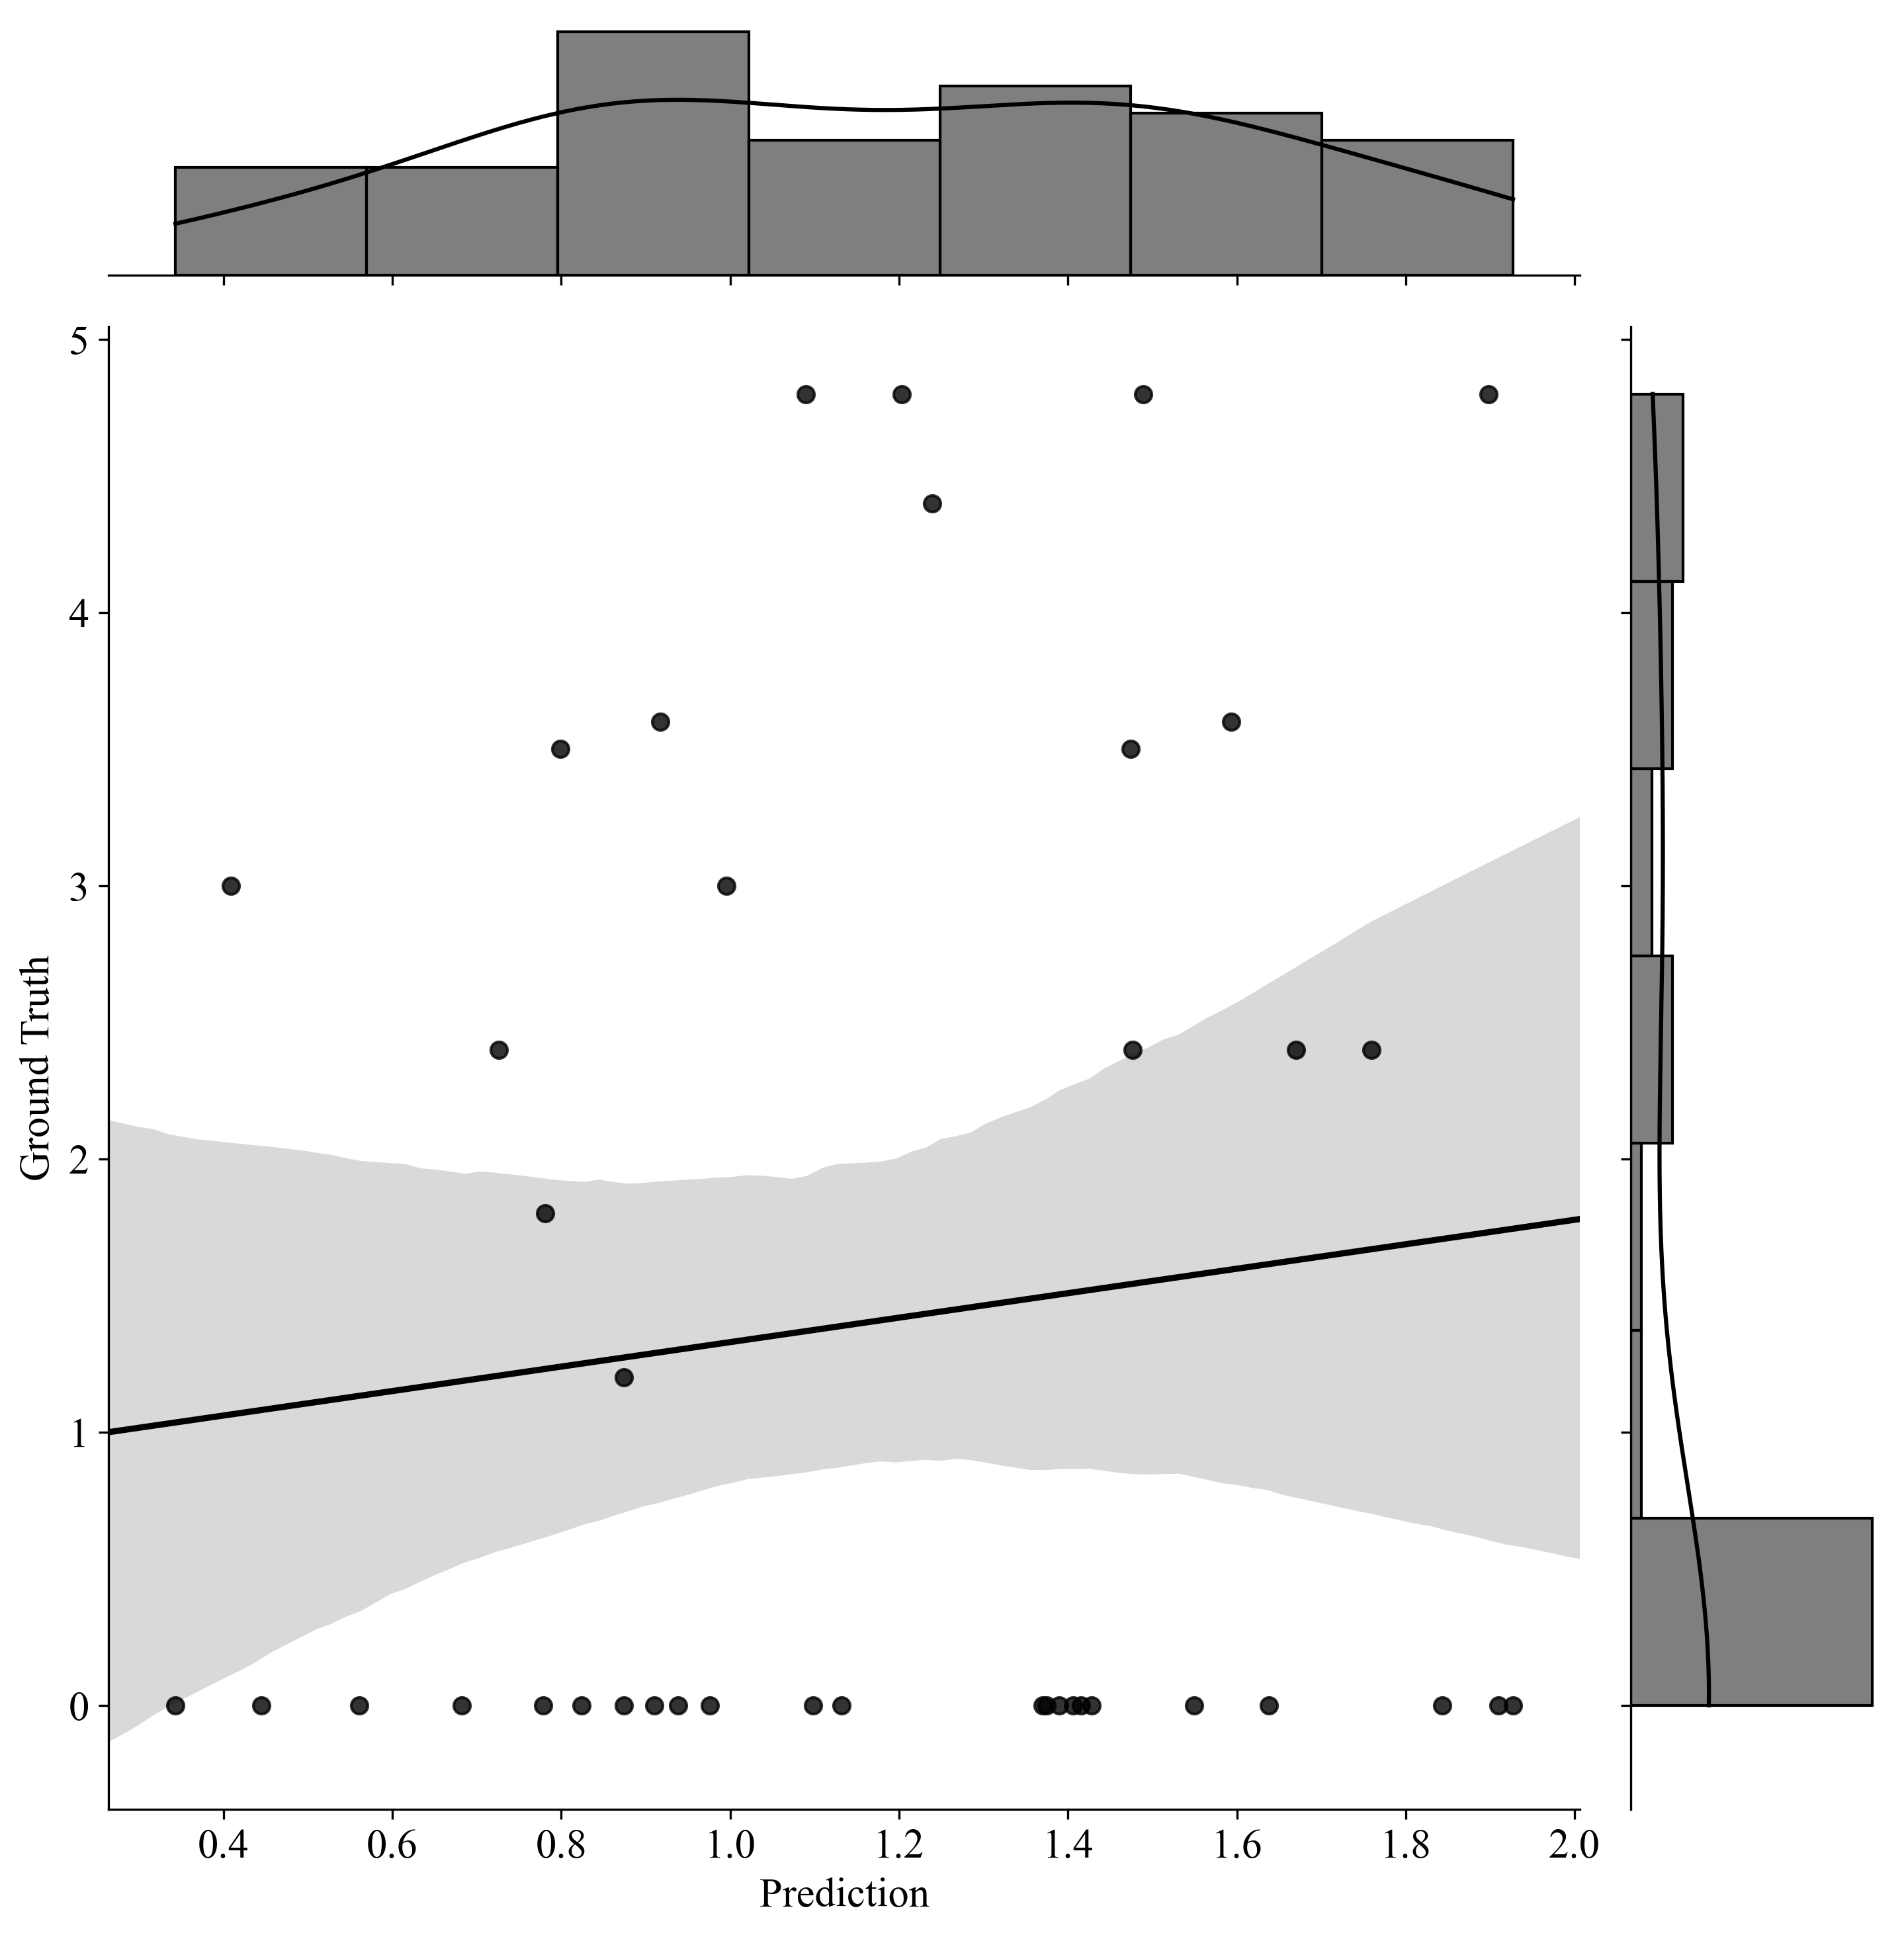

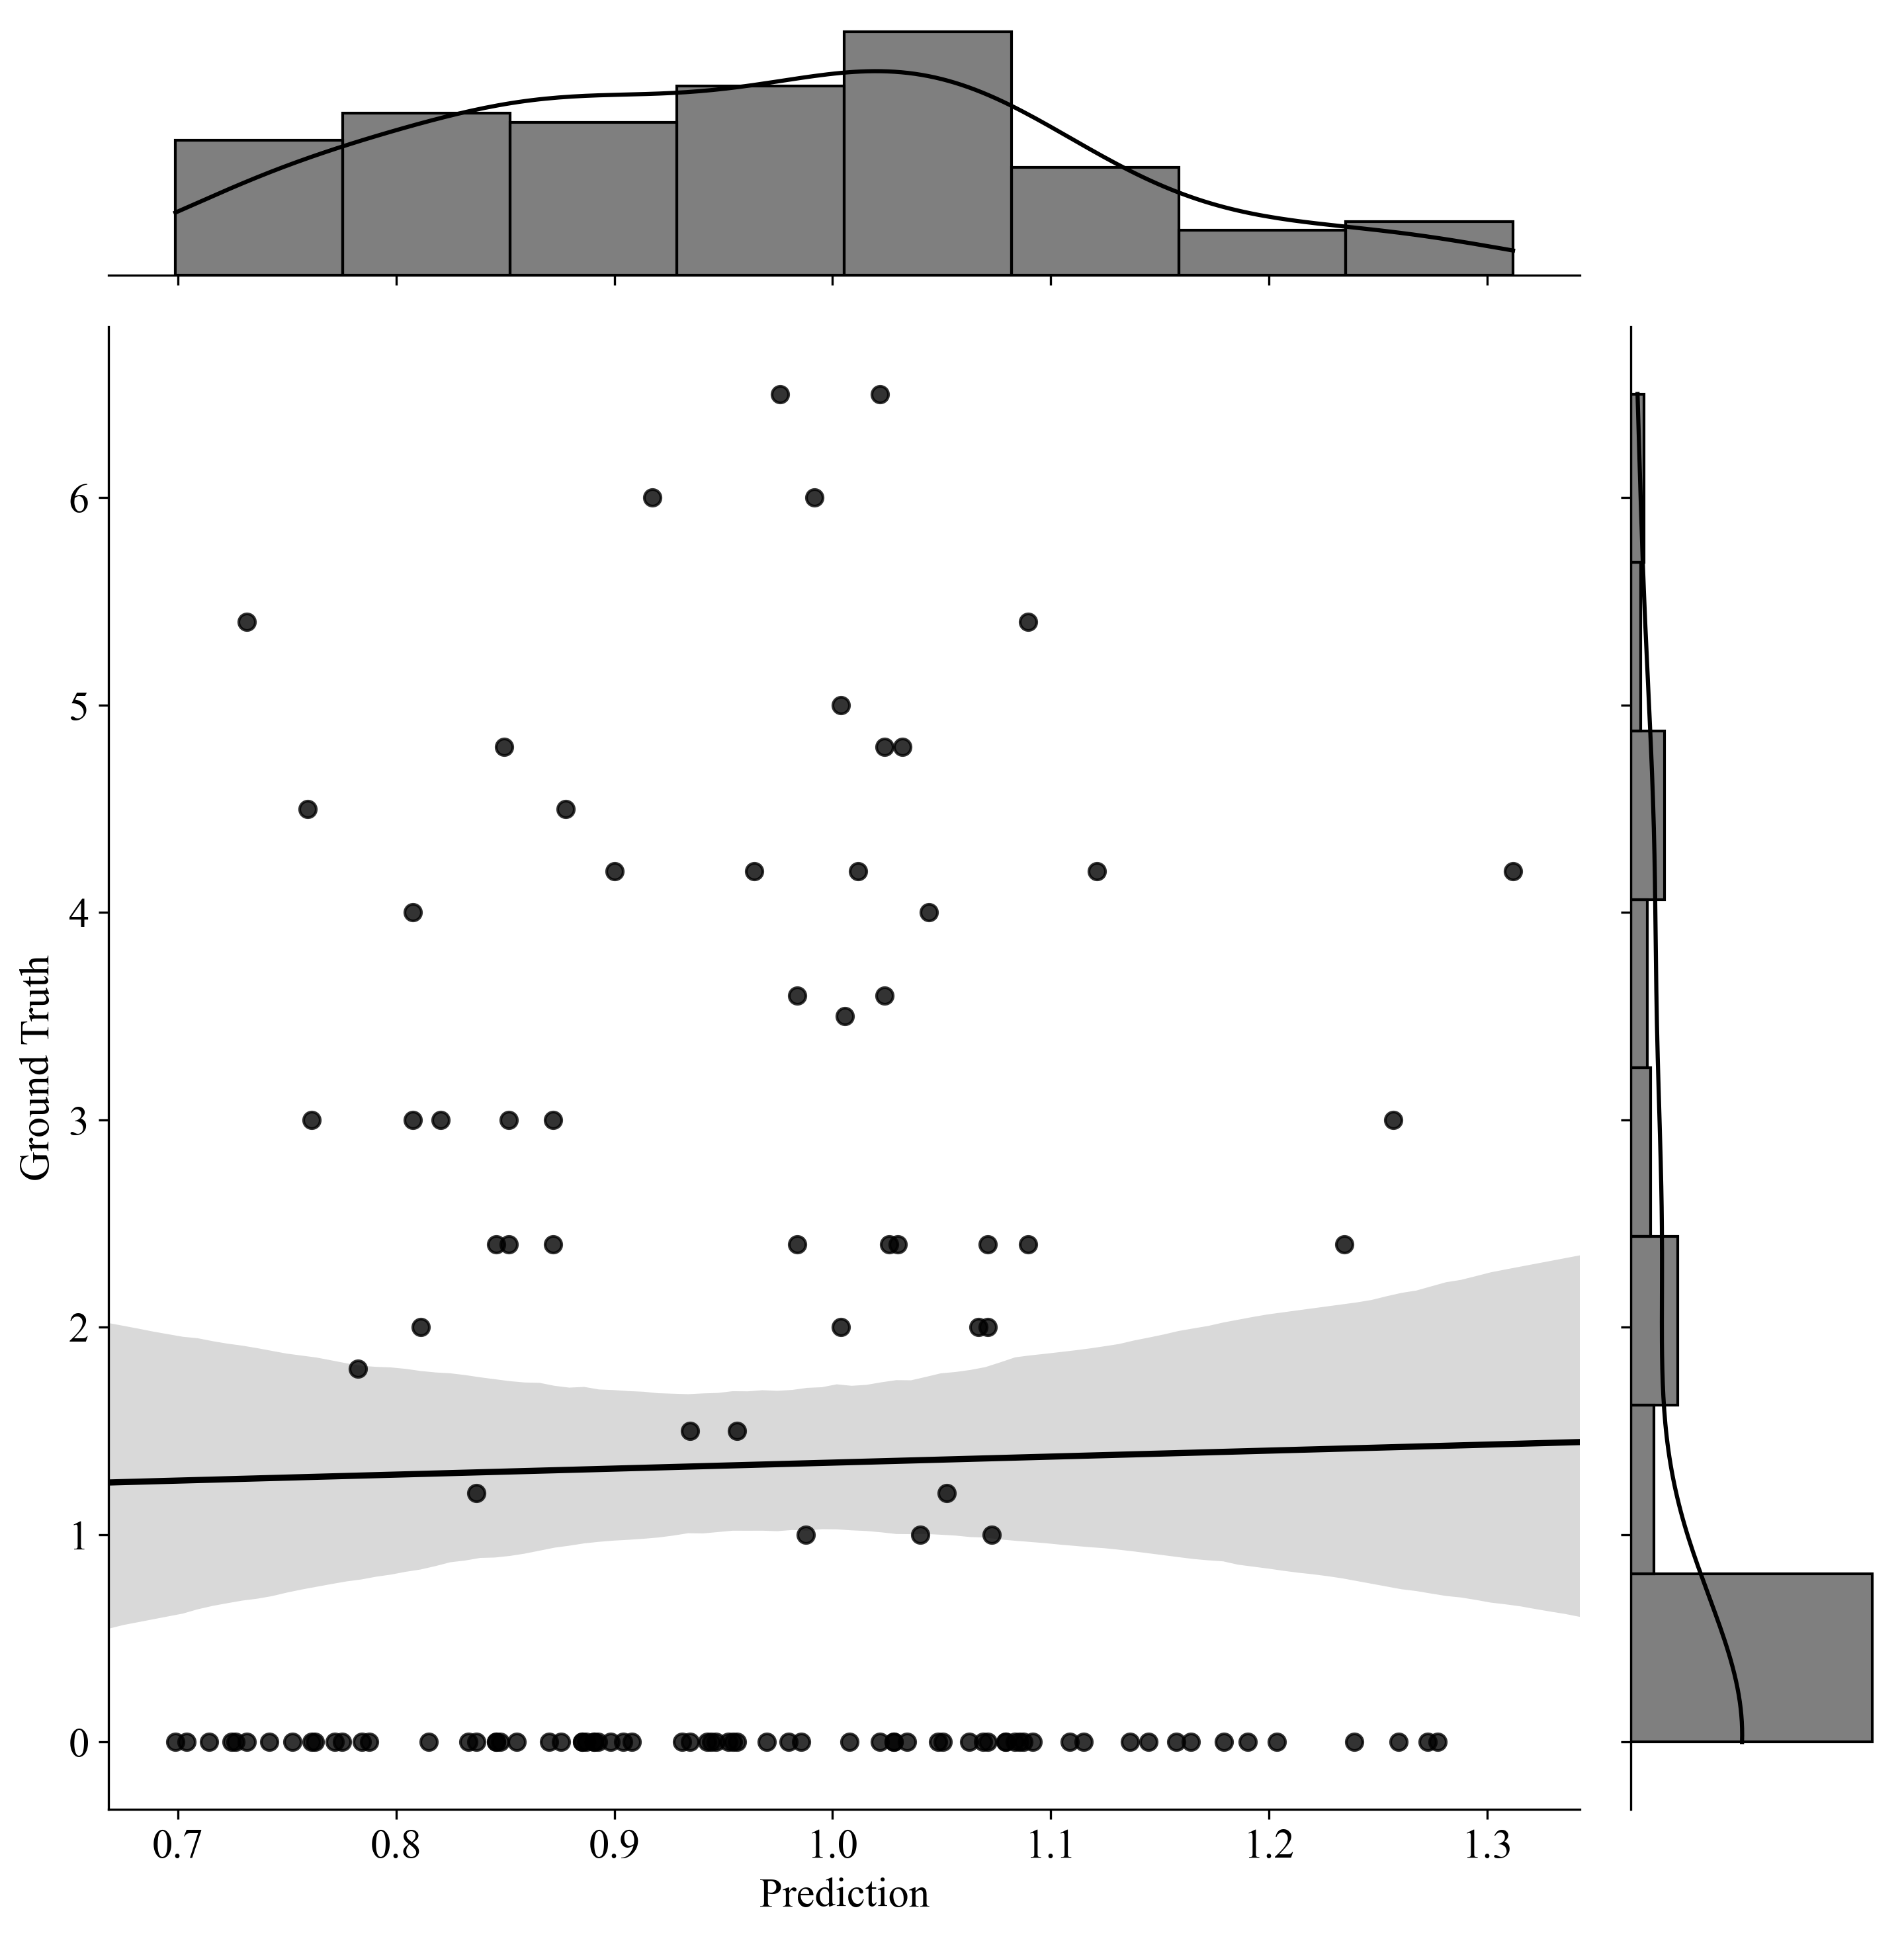

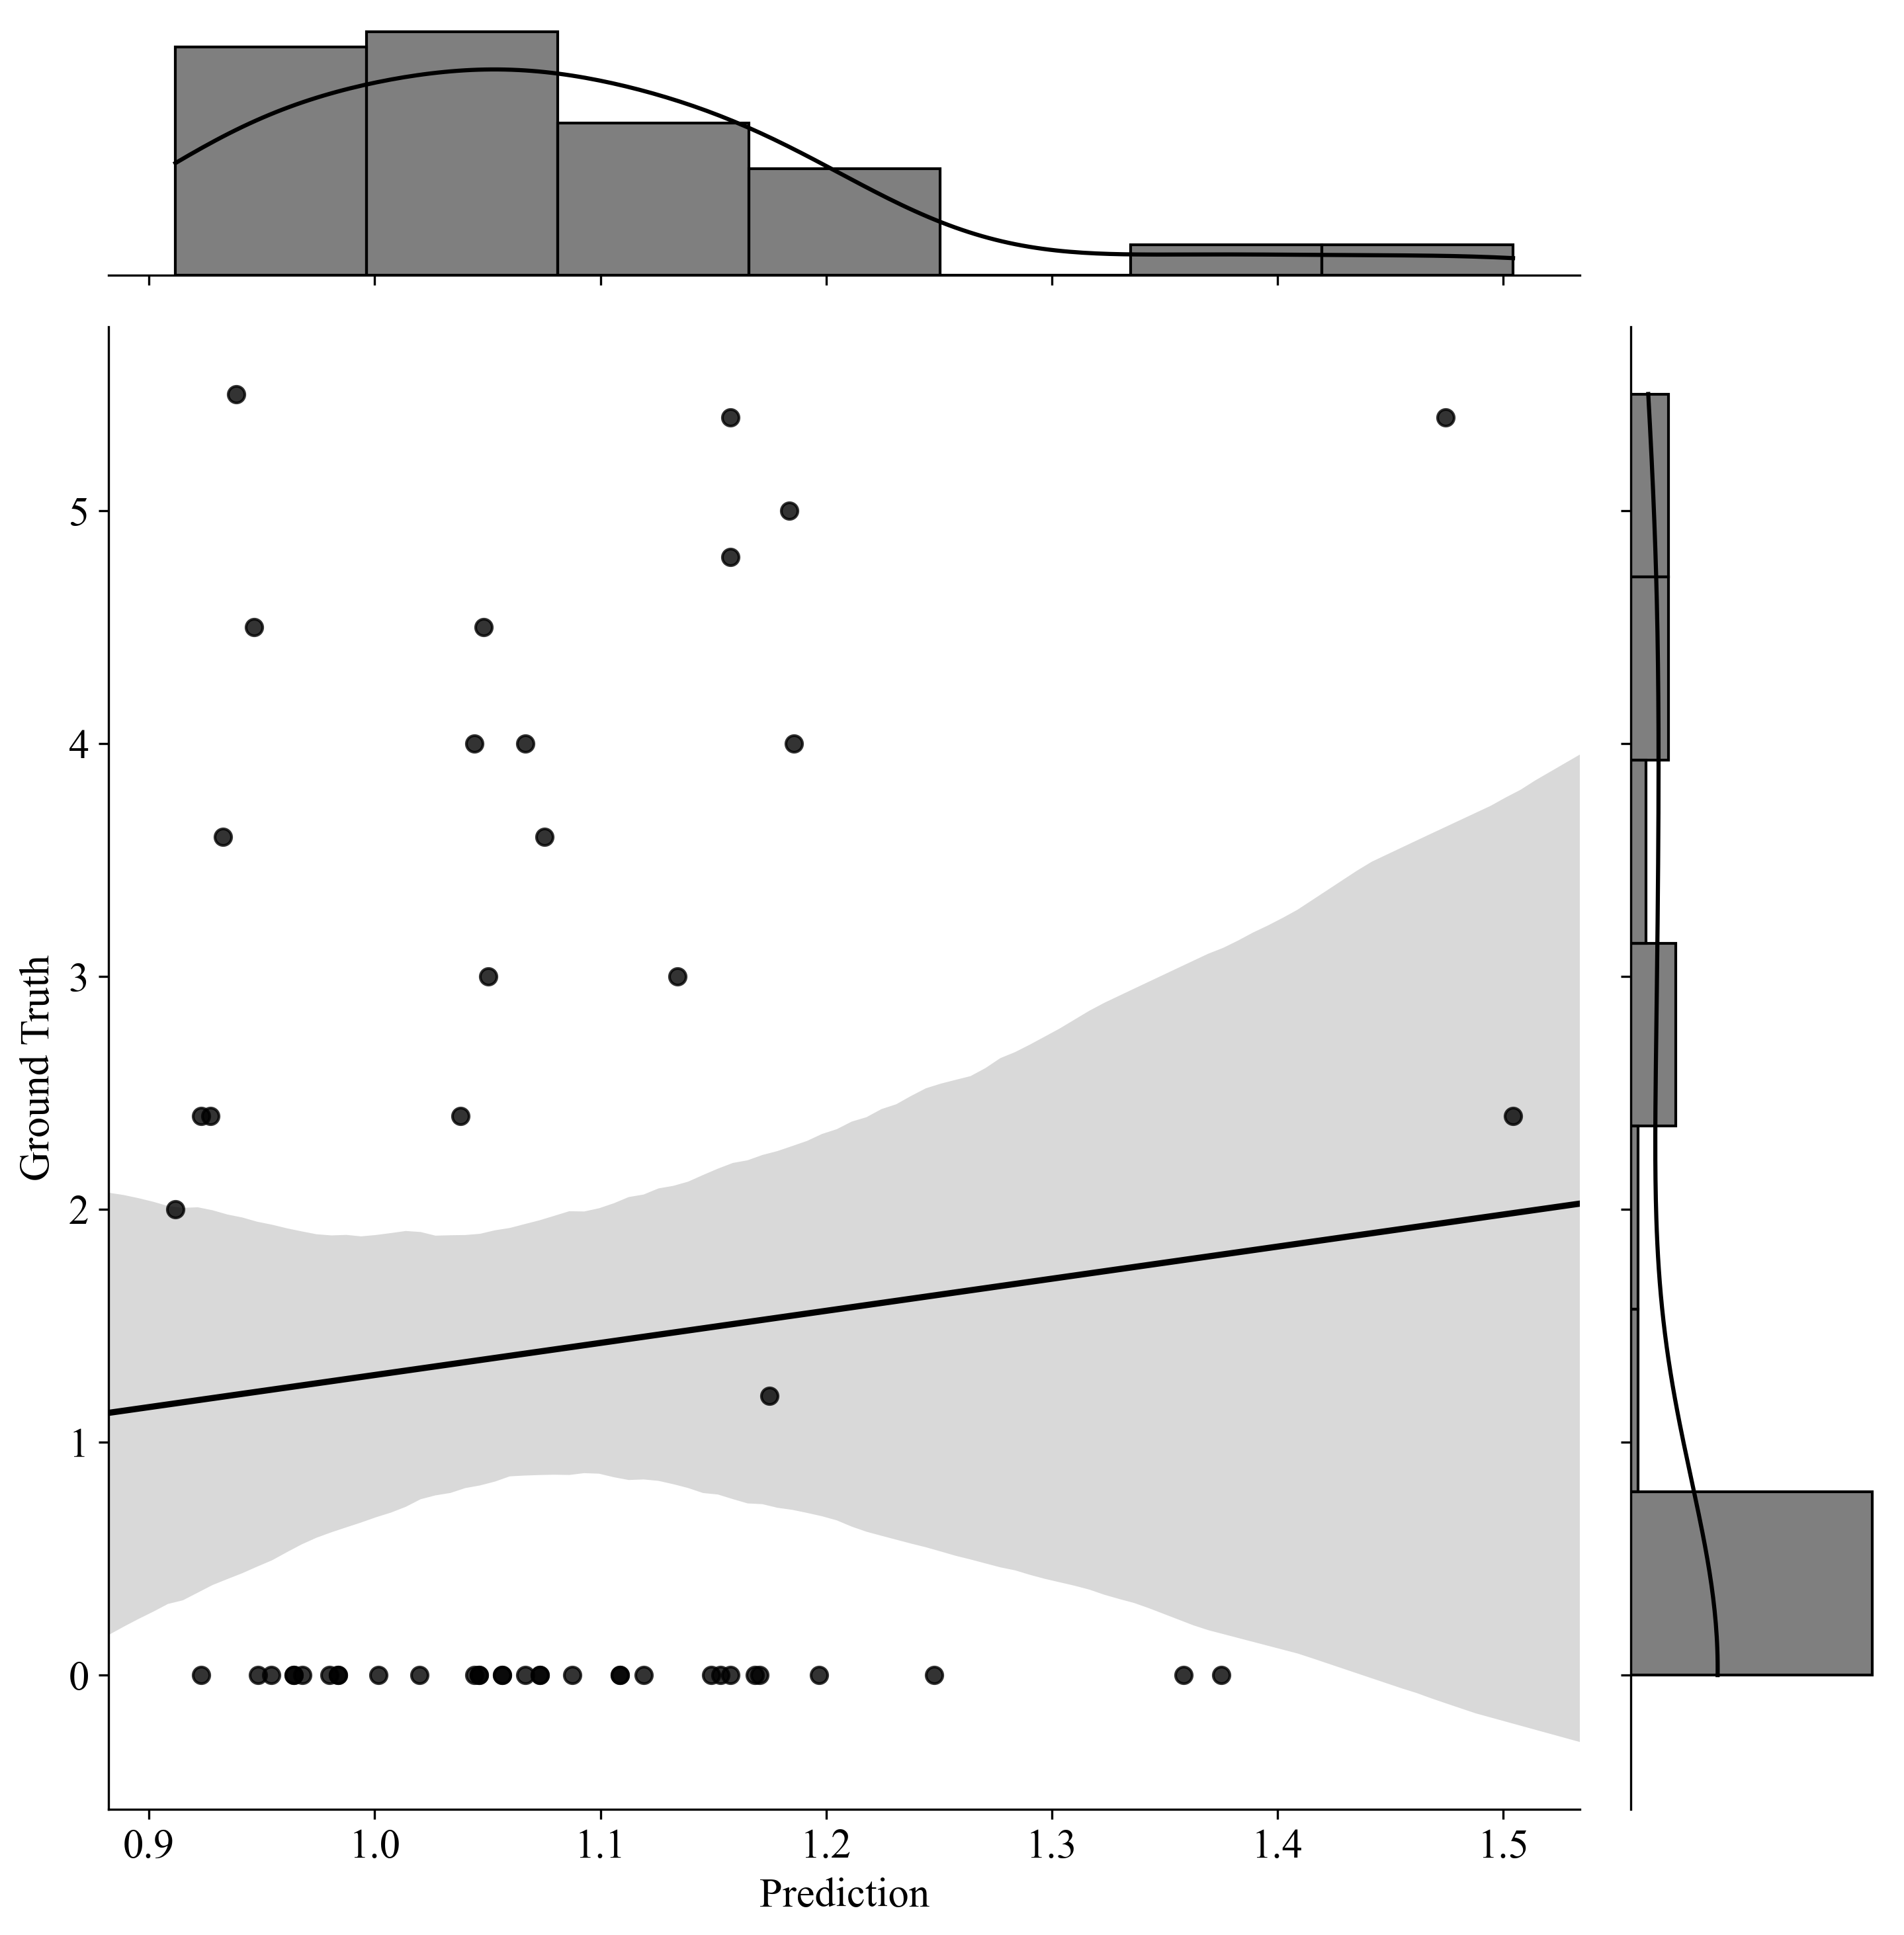

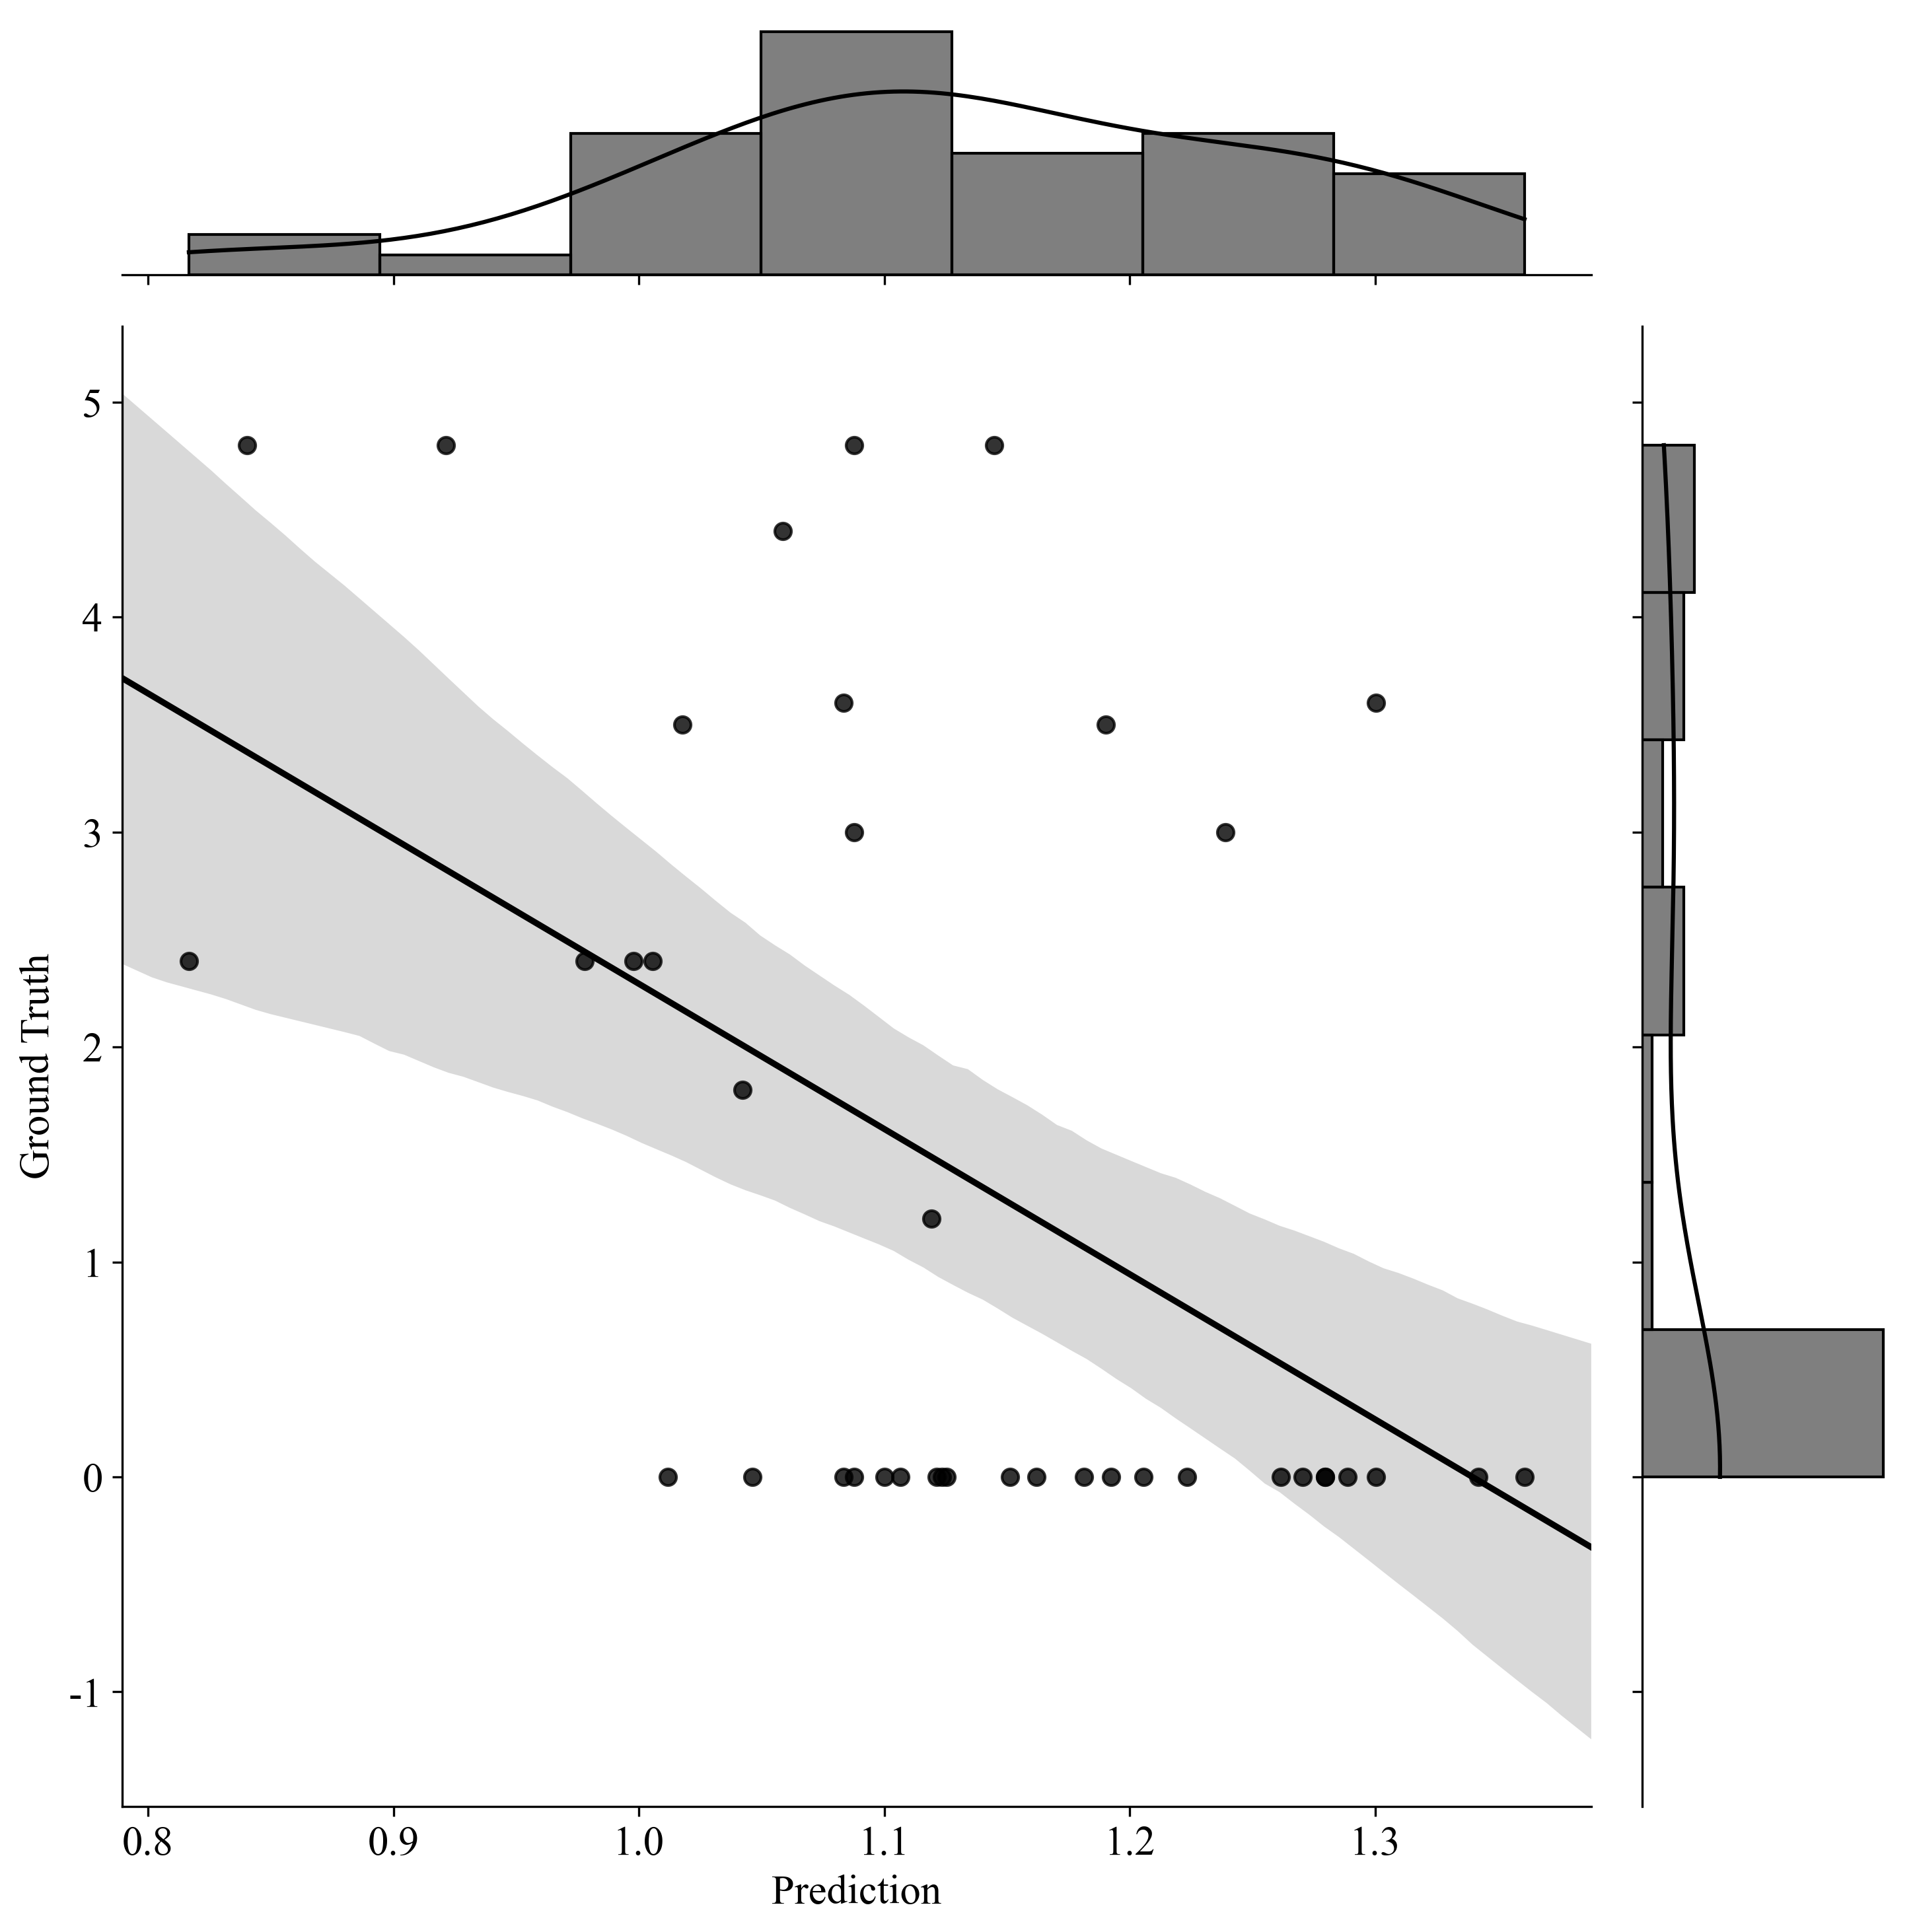

In [67]:
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def map2e(x):
    return math.exp(x) - 1

def remove_outliers_percentile(df, column, lower_percentile=1, upper_percentile=99):
    lower_limit = df[column].quantile(lower_percentile/100)
    upper_limit = df[column].quantile(upper_percentile/100)
    
    return df[(df[column] >= lower_limit) & (df[column] <= upper_limit)]

os.makedirs('img', exist_ok=True)
sns.set_palette(["black", "gray", "white"])

sel_model = 'densenet121'
for sel_model in models:
    log = pd.concat(logs, axis=0)
    log = log[log['model'] == sel_model]
    for subset in get_param_in_cwd('subsets'):
        val_log = log[log['group'] == subset].copy()
        for c in ['Prediction', 'Ground Truth']:
            val_log[c] = val_log[c].map(lambda x: map2e(x))
    #     display(val_log)
        val_log = remove_outliers_percentile(val_log, 'Ground Truth', lower_percentile=0, upper_percentile=90)
        sns.jointplot(y='Ground Truth', x=f'Prediction', data=val_log,  kind="reg", truncate=False, height=10)
        plt.savefig(f'img/{modal}_{sel_model}_{subset}_regression.svg', bbox_inches='tight')
        plt.show()